## Initial Data Preparation

In [28]:
import os

# Define the base directory
base_dir = '/content/drive/MyDrive/dataset'
# Define the folders and their corresponding labels
folder_labels = {
    'Benign': 0,
    'Early': 1,
    'Pre': 2,
    'Pro': 3
}

# Create lists to store images and labels
images = []
labels = []

print(f"Base directory: {base_dir}")
print(f"Folder labels: {folder_labels}")

Base directory: /content/drive/MyDrive/dataset
Folder labels: {'Benign': 0, 'Early': 1, 'Pre': 2, 'Pro': 3}


In [ ]:
# Iterate through the defined folders
for folder_name, label in folder_labels.items():
    folder_path = os.path.join(base_dir, folder_name)
    print(f"Processing folder: {folder_path}")

    # Check if the folder exists
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}. Skipping.")
        continue

    # Iterate through the files in the folder
    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)

        # Check if the file is an image (you might want to add more robust checks)
        if image_name.endswith(('.png', '.jpg', '.jpeg')):
            # Load the image
            img = cv2.imread(image_path)

            if img is not None:
                # Convert from BGR to RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = torch.from_numpy(img).permute(2, 0, 1)  # numpy → tensor, HWC → CHW
                # Append the image and label to the lists
                images.append(img)
                labels.append(label)
            else:
                print(f"Could not load image: {image_path}")
        else:
            print(f"Skipping non-image file: {image_path}")

print("Finished loading images and labels.")
print(f"Total images loaded: {len(images)}")
print(f"Total labels loaded: {len(labels)}")

In [ ]:
from collections import Counter

# Get the counts for each label
label_counts = Counter(labels)

print("Image counts per label:")
for label, count in label_counts.items():
    print(f"Label {label}: {count} images")

In [ ]:
data = torch.stack(images)          # shape: [N, C, H, W]
labels = torch.tensor(labels)     # shape: [N]

In [ ]:
torch.save((data, labels), "/content/drive/MyDrive/dataset.pt")

## Typical Workflow From Here

### Data Loading and Visualization

In [3]:
import torch

In [4]:
images, labels = torch.load("C:/Users/kusha/Downloads/dataset.pt")
print(images.shape, labels.shape)

C:\Users\kusha\AppData\Local\Temp\ipykernel_1516\638343055.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  images, labels = torch.load("C:/Users/kusha/Downloads/dataset.

torch.Size([3256, 3, 224, 224]) torch.Size([3256])


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

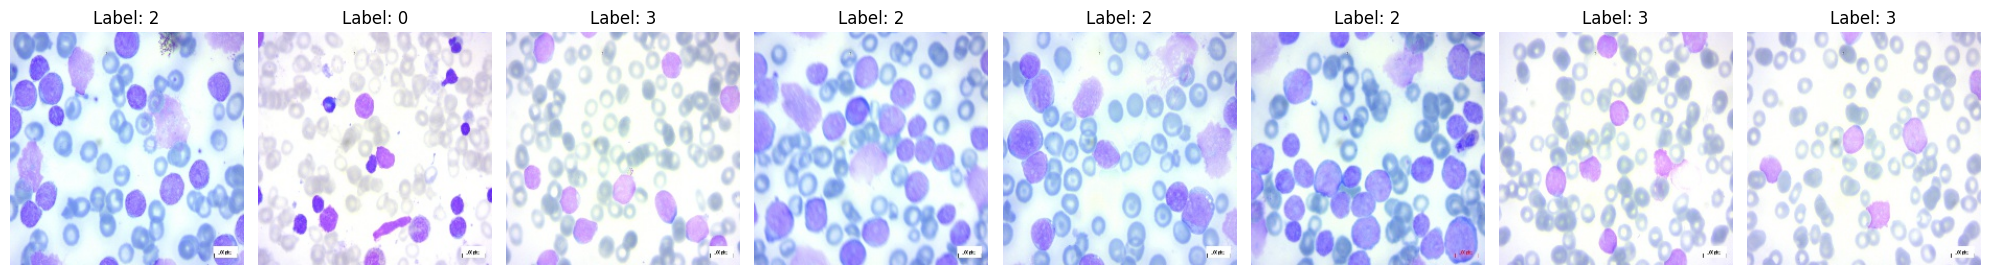

In [6]:
# Select 8 random indices
random_indices = np.random.choice(len(images), size=8, replace=False)

# Create a figure and subplots
fig, axes = plt.subplots(1, 8, figsize=(20, 5))

# Display each image in a subplot
for i, idx in enumerate(random_indices):
    image_to_display = images[idx]
    label_to_display = labels[idx]

    # Convert the image tensor to a NumPy array and change channel order from CHW to HWC
    image_np = image_to_display.permute(1, 2, 0).numpy()

    # Convert from BGR to RGB for correct display with Matplotlib
    image_rgb = cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB)

    axes[i].imshow(image_rgb)
    axes[i].set_title(f"Label: {label_to_display.item()}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Baseline Model training using raw pixels

In [7]:
# Reshape images into a 2D array (n_samples, n_features)
n_samples = images.shape[0]
n_features = images.shape[1] * images.shape[2] * images.shape[3]  # C * H * W
images_reshaped = images.view(n_samples, n_features)

print(f"Original images shape: {images.shape}")
print(f"Reshaped images shape: {images_reshaped.shape}")

Original images shape: torch.Size([3256, 3, 224, 224])
Reshaped images shape: torch.Size([3256, 150528])


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images_reshaped.numpy(), labels.numpy(), test_size=0.2, random_state=42, stratify=labels.numpy())

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

# Initialize and train the Random Forest Classifier
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Training data shape: (2604, 150528)
Testing data shape: (652, 150528)
Training labels shape: (2604,)
Testing labels shape: (652,)
Random Forest model trained successfully.


In [10]:
# Make predictions on the test set
y_pred = random_forest_model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Calculate and print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Print the classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.8680981595092024

Confusion Matrix:
[[ 50  32   1  18]
 [  9 188   0   0]
 [  6  19 167   1]
 [  0   0   0 161]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.50      0.60       101
           1       0.79      0.95      0.86       197
           2       0.99      0.87      0.93       193
           3       0.89      1.00      0.94       161

    accuracy                           0.87       652
   macro avg       0.86      0.83      0.83       652
weighted avg       0.87      0.87      0.86       652



### Train RF model on only medically relevant features

In [11]:
import pandas as pd

In [12]:

from skimage.measure import label, regionprops
import math
import warnings
warnings.filterwarnings("ignore")

# ---------------------------
# HELPERS
# ---------------------------
def safe_div(a, b, eps=1e-9):
    return a / (b + eps)

def circularity(area, perimeter):
    if perimeter <= 1e-6:
        return 0.0
    return (4.0 * math.pi * area) / (perimeter * perimeter)

# ---------------------------
# STORAGE
# ---------------------------
rows = []

# ---------------------------
# MAIN LOOP
# ---------------------------
for idx, img_tensor in enumerate(images):
    # Convert tensor -> HWC uint8
    img = img_tensor.permute(1,2,0).numpy()
    # Ensure uint8
    if img.dtype != np.uint8:
        # assume [0,1] or floats -> scale to 0-255
        img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    # Convert to grayscale
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    except:
        # fallback
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    H, W = gray.shape
    size = H * W

    features = {}
    # LABEL
    features['Label'] = int(labels[idx])

    # -------------------
    # SATURATION-BASED cytoplasm & nucleus masks
    # -------------------
    try:
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    except:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    Sc = hsv[:,:,1].astype(np.float32)
    
    # Common approach: S channel threshold to find cytoplasm (higher saturation)
    S_norm = Sc / 255.0
    s_thresh = S_norm.mean()
    cytoplasm_mask = S_norm > s_thresh
    

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    S_norm = hsv[:,:,1].astype(np.float32) / 255.0
    V_norm = hsv[:,:,2].astype(np.float32) / 255.0

    s_val = (S_norm * 255).astype(np.uint8)
    _, s_thresh_val = cv2.threshold(s_val, 0, 255, cv2.THRESH_OTSU)
    s_thresh = (s_thresh_val / 255.0) * 0.9

    nucleus_mask = (S_norm <= s_thresh) & (V_norm >= 0.9)  # low saturation + dark

    # Apply morphological opening to clean up the mask
    nucleus_mask_cleaned = cv2.morphologyEx(nucleus_mask.astype(np.uint8), cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

    lab = label(nucleus_mask_cleaned)
    cleaned = np.zeros_like(nucleus_mask_cleaned)
    for r in regionprops(lab):
        if 200 < r.area < 5000:
            cleaned[lab == r.label] = 1
    nucleus_mask = cleaned

    nuc_pixels = int(nucleus_mask.sum())
    cyto_pixels = int(cytoplasm_mask.sum())
    features['Nucleus_Pixels'] = nuc_pixels
    features['Cytoplasm_Pixels'] = cyto_pixels
    features['Nucleus_Ratio'] = float(nuc_pixels / size)
    features['Cytoplasm_Ratio'] = float(cyto_pixels / size)
    features['CytoNuc_Area_Ratio'] = float(safe_div(cyto_pixels, nuc_pixels))

    # -------------------
    # Cytoplasm-Nucleus color / intensity differences
    # -------------------
    try:
        cyto_mean = float(gray[cytoplasm_mask].mean())
    except:
        cyto_mean = 0.0
    try:
        nuc_mean = float(gray[nucleus_mask].mean())
    except:
        nuc_mean = 0.0
    features['CytoMean'] = cyto_mean
    features['NucMean'] = nuc_mean
    features['CytoNuc_MeanDiff'] = float(abs(cyto_mean - nuc_mean))

    # -------------------
    # THRESHOLD + regionprops (main object-based morphology)
    # -------------------
    thr = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU)[1]
    lab = label(thr)
    props = regionprops(lab)
    if len(props) > 0:
        # choose the largest region by area as representative
        props_sorted = sorted(props, key=lambda p: p.area, reverse=True)
        p = props_sorted[0]
        area = float(p.area)
        perimeter = float(p.perimeter if hasattr(p,'perimeter') else 0.0)
        features['Area'] = area
        features['Perimeter'] = perimeter
        features['Eccentricity'] = float(p.eccentricity)
        features['Solidity'] = float(p.solidity) if hasattr(p,'solidity') else 0.0
        features['Extent'] = float(p.extent)
        features['MajorAxisLength'] = float(p.major_axis_length) if hasattr(p,'major_axis_length') else 0.0
        features['MinorAxisLength'] = float(p.minor_axis_length) if hasattr(p,'minor_axis_length') else 0.0
        # Aspect ratio, circularity, compactness
        features['Aspect_Ratio'] = float(safe_div(p.major_axis_length, (p.minor_axis_length)))
        features['Circularity'] = float(circularity(area, perimeter))
        # convexity / convex area
        try:
            features['ConvexArea'] = float(p.convex_area)
            features['Convexity'] = float(safe_div(p.convex_area, area))
        except Exception:
            features['ConvexArea'] = 0.0
            features['Convexity'] = 0.0
    else:
        # zeros
        for k in ['Area','Perimeter','Eccentricity','Solidity','Extent','MajorAxisLength','MinorAxisLength',
                  'Aspect_Ratio','Circularity','ConvexArea','Convexity']:
            features[k] = 0.0

    # -------------------
    # Canny edges
    # -------------------
    edges = cv2.Canny(gray, 50, 150)
    features['Edge_Mean'] = float(edges.mean())
    features['Edge_Count'] = float(edges.sum() / 255.0)

    # -------------------
    # Additional composite features
    # -------------------
    features['Nuc_vs_Cyto_MeanRatio'] = float(safe_div(nuc_mean, (cyto_mean + 1e-9)))

    # -------------------
    # collect row
    rows.append(features)

# ---------------------------
# BUILD DataFrame
# ---------------------------
df = pd.DataFrame(rows)
# ensure deterministic column order: Label first
cols = df.columns.tolist()
if 'Label' in cols:
    cols = ['Label'] + [c for c in cols if c != 'Label']
df = df[cols]

print("Final columns:", len(df.columns))
print(df.head())
print("Final shape:", df.shape)

Final columns: 23
   Label  Nucleus_Pixels  Cytoplasm_Pixels  Nucleus_Ratio  Cytoplasm_Ratio  \
0      0            5875             18608       0.117088         0.370855   
1      0            3522             12533       0.070193         0.249781   
2      0            1167             15270       0.023258         0.304329   
3      0            4906             23976       0.097776         0.477838   
4      0            2449             14837       0.048808         0.295699   

   CytoNuc_Area_Ratio    CytoMean     NucMean  CytoNuc_MeanDiff     Area  ...  \
0            3.167319  190.459319  212.269553         21.810234  19570.0  ...   
1            3.558489  218.034868  241.589921         23.555053  48439.0  ...   
2           13.084833  196.625344  218.337420         21.712077  47199.0  ...   
3            4.887077  192.859860  198.702598          5.842738  19800.0  ...   
4            6.058391  182.231988  205.972768         23.740781  42127.0  ...   

     Extent  MajorAxisLeng

In [13]:
# Display the list of column names in the df DataFrame
print("Columns in df:")
print(df.columns.tolist())

Columns in df:
['Label', 'Nucleus_Pixels', 'Cytoplasm_Pixels', 'Nucleus_Ratio', 'Cytoplasm_Ratio', 'CytoNuc_Area_Ratio', 'CytoMean', 'NucMean', 'CytoNuc_MeanDiff', 'Area', 'Perimeter', 'Eccentricity', 'Solidity', 'Extent', 'MajorAxisLength', 'MinorAxisLength', 'Aspect_Ratio', 'Circularity', 'ConvexArea', 'Convexity', 'Edge_Mean', 'Edge_Count', 'Nuc_vs_Cyto_MeanRatio']


In [14]:
# Check for missing values in the features_df
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
Label                    0
Nucleus_Pixels           0
Cytoplasm_Pixels         0
Nucleus_Ratio            0
Cytoplasm_Ratio          0
CytoNuc_Area_Ratio       0
CytoMean                 0
NucMean                  0
CytoNuc_MeanDiff         0
Area                     0
Perimeter                0
Eccentricity             0
Solidity                 0
Extent                   0
MajorAxisLength          0
MinorAxisLength          0
Aspect_Ratio             0
Circularity              0
ConvexArea               0
Convexity                0
Edge_Mean                0
Edge_Count               0
Nuc_vs_Cyto_MeanRatio    0
dtype: int64


In [15]:
# Separate features (X) and target (y)
X = df.drop('Label', axis=1)  # Exclude the 'Label' column from features
y = labels.numpy() # Ensure labels are in NumPy format

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

# Initialize and train the Random Forest Classifier
random_forest_model_medical = RandomForestClassifier(n_estimators=250, random_state=42)
random_forest_model_medical.fit(X_train, y_train)

print("Random Forest model trained successfully with medically relevant features.")

# Make predictions on the test set
y_pred_medical = random_forest_model_medical.predict(X_test)

# Calculate and print the accuracy
accuracy_medical = accuracy_score(y_test, y_pred_medical)
print(f"\nAccuracy: {accuracy_medical}")

# Calculate and print the confusion matrix
conf_matrix_medical = confusion_matrix(y_test, y_pred_medical)
print("\nConfusion Matrix:")
print(conf_matrix_medical)

# Print the classification report
class_report_medical = classification_report(y_test, y_pred_medical)
print("\nClassification Report:")
print(class_report_medical)

Training data shape: (2604, 22)
Testing data shape: (652, 22)
Training labels shape: (2604,)
Testing labels shape: (652,)
Random Forest model trained successfully with medically relevant features.

Accuracy: 0.9386503067484663

Confusion Matrix:
[[ 88   6   2   5]
 [  5 183   3   6]
 [  2   5 185   1]
 [  0   5   0 156]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       101
           1       0.92      0.93      0.92       197
           2       0.97      0.96      0.97       193
           3       0.93      0.97      0.95       161

    accuracy                           0.94       652
   macro avg       0.94      0.93      0.93       652
weighted avg       0.94      0.94      0.94       652



In [16]:
import seaborn as sns

Top 20 Most Important Features:


,Feature,Importance
5,CytoMean,0.140459
2,Nucleus_Ratio,0.101626
3,Cytoplasm_Ratio,0.091173
1,Cytoplasm_Pixels,0.087988
0,Nucleus_Pixels,0.086425
4,CytoNuc_Area_Ratio,0.067513
18,Convexity,0.049736
19,Edge_Mean,0.043290
11,Solidity,0.041743
20,Edge_Count,0.041091


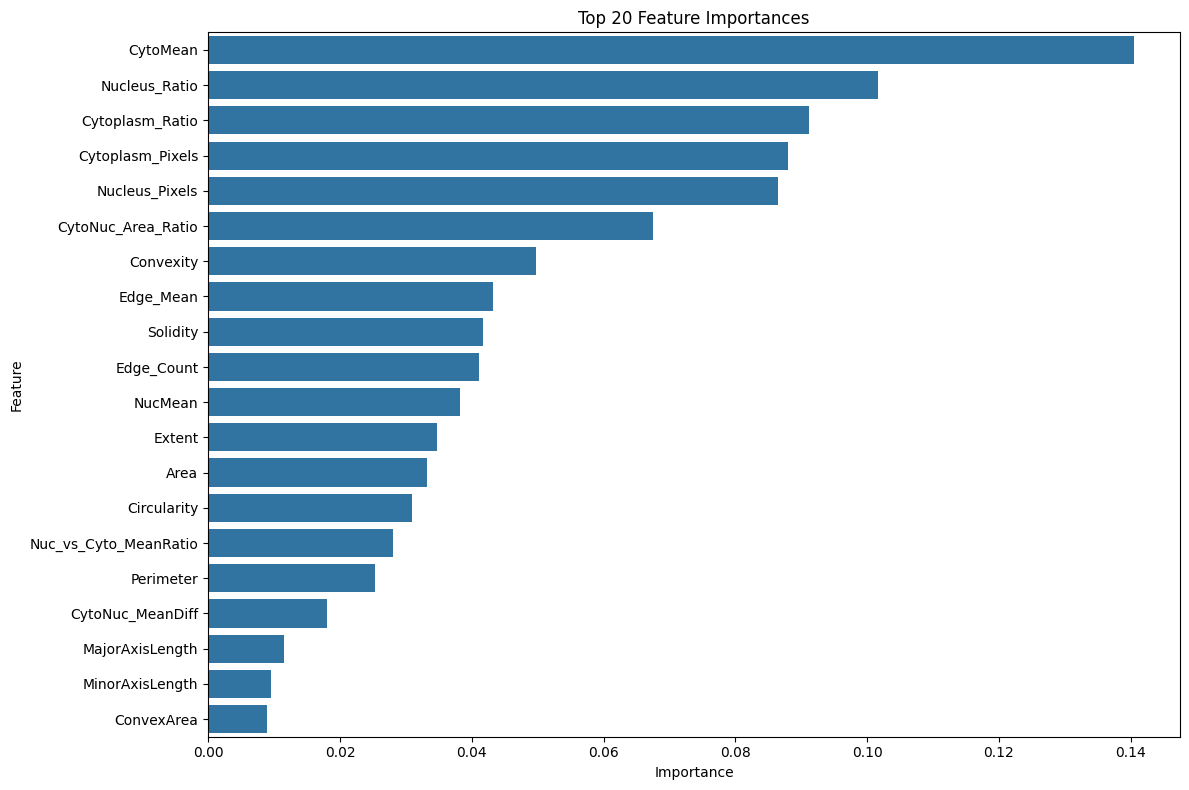

In [17]:
# Get feature importances from the trained model
feature_importances = random_forest_model_medical.feature_importances_

# Pair feature names with their importance scores
features = X_train.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top N most important features (e.g., top 20)
print("Top 20 Most Important Features:")
display(importance_df.head(30))

# Optionally, visualize the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Find best model for medically relevant features

In [18]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

import time

# Dictionary to store results
results = {}

# List of models to train
models = {
    'Random Forest (250 trees)': RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1),
    'Random Forest (500 trees)': RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss'),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVM (RBF kernel)': SVC(kernel='rbf', random_state=42, probability=True),
    'K-Nearest Neighbors (k=5)': KNeighborsClassifier(n_neighbors=5),
    'K-Nearest Neighbors (k=10)': KNeighborsClassifier(n_neighbors=10),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10)
}

print("Training and evaluating models...\n")
print("="*80)

# Train and evaluate each model
for model_name, model in models.items():
    print(f"\n{model_name}")
    print("-" * 80)
    
    # Start timer
    start_time = time.time()
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    conf_mat = confusion_matrix(y_test, y_pred)
    
    # Training time
    training_time = time.time() - start_time
    
    # Store results
    results[model_name] = {
        'accuracy': accuracy,
        'confusion_matrix': conf_mat,
        'training_time': training_time,
        'model': model
    }
    
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Training Time: {training_time:.2f} seconds")
    print(f"Confusion Matrix:\n{conf_mat}")

print("\n" + "="*80)
print("\nMODEL COMPARISON SUMMARY")
print("="*80)

# Sort models by accuracy
sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)

print(f"\n{'Rank':<5} {'Model':<35} {'Accuracy':<12} {'Time (s)':<10}")
print("-" * 80)

for rank, (model_name, result) in enumerate(sorted_results, 1):
    print(f"{rank:<5} {model_name:<35} {result['accuracy']*100:>6.2f}%    {result['training_time']:>8.2f}s")

# Get the best model
best_model_name = sorted_results[0][0]
best_model_result = sorted_results[0][1]

print("\n" + "="*80)
print(f"\nBEST MODEL: {best_model_name}")
print(f"Accuracy: {best_model_result['accuracy']*100:.2f}%")
print(f"\nDetailed Classification Report:")
print("-" * 80)
y_pred_best = best_model_result['model'].predict(X_test)
print(classification_report(y_test, y_pred_best))

Training and evaluating models...


Random Forest (250 trees)
--------------------------------------------------------------------------------
Accuracy: 0.9387 (93.87%)
Training Time: 0.55 seconds
Confusion Matrix:
[[ 88   6   2   5]
 [  5 183   3   6]
 [  2   5 185   1]
 [  0   5   0 156]]

Random Forest (500 trees)
--------------------------------------------------------------------------------
Accuracy: 0.9402 (94.02%)
Training Time: 0.98 seconds
Confusion Matrix:
[[ 88   6   2   5]
 [  5 184   2   6]
 [  2   5 185   1]
 [  0   5   0 156]]

Gradient Boosting
--------------------------------------------------------------------------------
Accuracy: 0.9479 (94.79%)
Training Time: 17.13 seconds
Confusion Matrix:
[[ 87   8   1   5]
 [  3 187   1   6]
 [  2   5 186   0]
 [  0   3   0 158]]

XGBoost
--------------------------------------------------------------------------------
Accuracy: 0.9525 (95.25%)
Training Time: 0.69 seconds
Confusion Matrix:
[[ 88   8   0   5]
 [  3 188   1   5]
 

In [20]:
import lightgbm as lgb

In [21]:
print("\nLightGBM Classifier")
print("-" * 80)
start_time = time.time()

lgbm_model = lgb.LGBMClassifier(
    num_leaves=64, 
    learning_rate=0.03, 
    n_estimators=1000,
    random_state=42,
    verbose=-1  # Suppress warnings
)
lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)
lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
lgbm_time = time.time() - start_time

print(f"LightGBM Accuracy: {lgbm_accuracy:.4f} ({lgbm_accuracy*100:.2f}%)")
print(f"Training Time: {lgbm_time:.2f} seconds")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, lgbm_pred)}")


LightGBM Classifier
--------------------------------------------------------------------------------
LightGBM Accuracy: 0.9571 (95.71%)
Training Time: 2.40 seconds
Confusion Matrix:
[[ 92   4   1   4]
 [  3 187   2   5]
 [  1   1 189   2]
 [  0   5   0 156]]


In [25]:
advanced_results = {
    'LightGBM': lgbm_accuracy,
}

# Combine with previous results
all_results = {name: result['accuracy'] for name, result in results.items()}
all_results.update(advanced_results)

# Sort all results
sorted_all = sorted(all_results.items(), key=lambda x: x[1], reverse=True)

print(f"\n{'Rank':<5} {'Model':<40} {'Accuracy':<12}")
print("-" * 80)

for rank, (model_name, acc) in enumerate(sorted_all, 1):
    marker = " <= BEST!" if rank == 1 else ""
    print(f"{rank:<5} {model_name:<40} {acc*100:>6.2f}%{marker}")

# Display detailed report for top 3 models
print("\n" + "="*80)
print("TOP 3 MODELS - DETAILED REPORTS")
print("="*80)

for rank, (model_name, acc) in enumerate(sorted_all[:3], 1):
    print(f"\n{rank}. {model_name} - Accuracy: {acc*100:.2f}%")
    print("-" * 80)
    
    if model_name == 'LightGBM':
        print(classification_report(y_test, lgbm_pred))
    elif model_name == 'Stacking Ensemble':
        print(classification_report(y_test, stacking_pred))
    elif model_name in results:
        pred = results[model_name]['model'].predict(X_test)
        print(classification_report(y_test, pred))


Rank  Model                                    Accuracy    
--------------------------------------------------------------------------------
1     LightGBM                                  95.71% <= BEST!
2     XGBoost                                   95.25%
3     Gradient Boosting                         94.79%
4     Random Forest (500 trees)                 94.02%
5     Random Forest (250 trees)                 93.87%
6     K-Nearest Neighbors (k=5)                 90.64%
7     K-Nearest Neighbors (k=10)                90.64%
8     Decision Tree                             90.49%
9     AdaBoost                                  76.99%
10    SVM (RBF kernel)                          30.37%
11    Naive Bayes                               29.91%
12    Logistic Regression                       26.99%

TOP 3 MODELS - DETAILED REPORTS

1. LightGBM - Accuracy: 95.71%
--------------------------------------------------------------------------------
              precision    recall  f1-score

### Finetune model

In [26]:
num_leaves_list = [32, 64, 128]
learning_rate_list = [0.01, 0.02, 0.03, 0.04]
num_estimators_list = [500, 800, 1000, 1200, 1500]

for num_leaves in num_leaves_list:
    for learning_rate in learning_rate_list:
        for num_estimators in num_estimators_list:
            start_time = time.time()
            model = lgb.LGBMClassifier(
                num_leaves=num_leaves,
                learning_rate=learning_rate,
                n_estimators=num_estimators,
                random_state=42,
                verbose=-1  # Suppress warnings
            )
            model.fit(X_train, y_train)
            lgbm_pred = model.predict(X_test)
            lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
            lgbm_time = time.time() - start_time

            print(
                f"num_leaves={num_leaves}, "
                f"learning_rate={learning_rate}, "
                f"n_estimators={num_estimators} → "
                f"Accuracy: {lgbm_accuracy:.4f}, "
                f"Time: {lgbm_time:.2f}s"
            )


num_leaves=32, learning_rate=0.01, n_estimators=500 → Accuracy: 0.9571, Time: 1.28s
num_leaves=32, learning_rate=0.01, n_estimators=800 → Accuracy: 0.9540, Time: 2.09s
num_leaves=32, learning_rate=0.01, n_estimators=1000 → Accuracy: 0.9540, Time: 2.73s
num_leaves=32, learning_rate=0.01, n_estimators=1200 → Accuracy: 0.9540, Time: 3.38s
num_leaves=32, learning_rate=0.01, n_estimators=1500 → Accuracy: 0.9555, Time: 4.26s
num_leaves=32, learning_rate=0.02, n_estimators=500 → Accuracy: 0.9540, Time: 1.40s
num_leaves=32, learning_rate=0.02, n_estimators=800 → Accuracy: 0.9540, Time: 1.88s
num_leaves=32, learning_rate=0.02, n_estimators=1000 → Accuracy: 0.9555, Time: 2.28s
num_leaves=32, learning_rate=0.02, n_estimators=1200 → Accuracy: 0.9555, Time: 2.66s
num_leaves=32, learning_rate=0.02, n_estimators=1500 → Accuracy: 0.9555, Time: 3.03s
num_leaves=32, learning_rate=0.03, n_estimators=500 → Accuracy: 0.9555, Time: 1.31s
num_leaves=32, learning_rate=0.03, n_estimators=800 → Accuracy: 0.9571

In [30]:
start_time = time.time()
best_model = lgb.LGBMClassifier(
    num_leaves=64, 
    learning_rate=0.02, 
    n_estimators=800,
    random_state=42,
    verbose=-1  # Suppress warnings
)
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, best_pred)
best_time = time.time() - start_time

print(f"Best Model (LightGBM) Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"Training Time: {best_time:.2f} seconds")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, best_pred)}")

Best Model (LightGBM) Accuracy: 0.9601 (96.01%)
Training Time: 3.90 seconds
Confusion Matrix:
[[ 93   4   1   3]
 [  3 188   2   4]
 [  1   1 189   2]
 [  0   5   0 156]]


### Remove redundant features

In [31]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)
print(feature_importance)

                  feature  importance
1        Cytoplasm_Pixels       19021
19              Edge_Mean       14756
5                CytoMean       14202
0          Nucleus_Pixels       13373
4      CytoNuc_Area_Ratio        9391
16            Circularity        7517
9               Perimeter        7394
13        MajorAxisLength        7370
6                 NucMean        7045
17             ConvexArea        5697
11               Solidity        5682
14        MinorAxisLength        5076
8                    Area        4940
7        CytoNuc_MeanDiff        4820
10           Eccentricity        4442
21  Nuc_vs_Cyto_MeanRatio        4138
18              Convexity        3612
12                 Extent        3148
2           Nucleus_Ratio           0
3         Cytoplasm_Ratio           0
15           Aspect_Ratio           0
20             Edge_Count           0


In [32]:
# Remove features with 0 importance
nonzero_features = feature_importance.query("importance > 0")["feature"].tolist()

# Create new X_train and X_test with only important features
X_train_reduced = X_train[nonzero_features].copy()
X_test_reduced = X_test[nonzero_features].copy()

print(f"Reduced feature count: {len(nonzero_features)} / {X_train.shape[1]}")
print("Remaining features:", nonzero_features)

Reduced feature count: 18 / 22
Remaining features: ['Cytoplasm_Pixels', 'Edge_Mean', 'CytoMean', 'Nucleus_Pixels', 'CytoNuc_Area_Ratio', 'Circularity', 'Perimeter', 'MajorAxisLength', 'NucMean', 'ConvexArea', 'Solidity', 'MinorAxisLength', 'Area', 'CytoNuc_MeanDiff', 'Eccentricity', 'Nuc_vs_Cyto_MeanRatio', 'Convexity', 'Extent']


In [33]:
start_time = time.time()
best_model = lgb.LGBMClassifier(
    num_leaves=64, 
    learning_rate=0.02, 
    n_estimators=800,
    random_state=42,
    verbose=-1  # Suppress warnings
)
best_model.fit(X_train_reduced, y_train)
best_pred = best_model.predict(X_test_reduced)
best_accuracy = accuracy_score(y_test, best_pred)
best_time = time.time() - start_time

print(f"Best Model (LightGBM) Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"Training Time: {best_time:.2f} seconds")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, best_pred)}")

Best Model (LightGBM) Accuracy: 0.9601 (96.01%)
Training Time: 4.79 seconds
Confusion Matrix:
[[ 92   4   1   4]
 [  3 188   2   4]
 [  1   1 189   2]
 [  0   4   0 157]]


### Diagnostic Thresholds (Normal [0] vs Abnormal [1, 2, 3])

In [34]:
from sklearn.metrics import roc_curve, auc
from scipy import stats

warnings.filterwarnings('ignore')

# Create binary labels: 0 = normal, 1 = abnormal (combining 1, 2, 3)
y_train_binary = (y_train > 0).astype(int)
y_test_binary = (y_test > 0).astype(int)

print("Binary label distribution:")
print(f"Training: Normal={sum(y_train_binary==0)}, Abnormal={sum(y_train_binary==1)}")
print(f"Testing: Normal={sum(y_test_binary==0)}, Abnormal={sum(y_test_binary==1)}")

# Dictionary to store threshold information
threshold_results = {}

Binary label distribution:
Training: Normal=403, Abnormal=2201
Testing: Normal=101, Abnormal=551


In [36]:
## Approach 1: ROC Curve Analysis - Find Optimal Threshold Using Youden's Index

for feature in X_train_reduced.columns:
    feature_values = X_train_reduced[feature].values
    
    # For features where higher values indicate abnormality
    fpr, tpr, thresholds = roc_curve(y_train_binary, feature_values)
    roc_auc = auc(fpr, tpr)
    
    # Youden's index (J = Sensitivity + Specificity - 1)
    youden_index = tpr - fpr
    optimal_idx = np.argmax(youden_index)
    optimal_threshold = thresholds[optimal_idx]
    optimal_sensitivity = tpr[optimal_idx]
    optimal_specificity = 1 - fpr[optimal_idx]
    # For features where lower values indicate abnormality (reverse)
    fpr_rev, tpr_rev, thresholds_rev = roc_curve(y_train_binary, -feature_values)
    roc_auc_rev = auc(fpr_rev, tpr_rev)
    
    youden_index_rev = tpr_rev - fpr_rev
    optimal_idx_rev = np.argmax(youden_index_rev)
    optimal_threshold_rev = -thresholds_rev[optimal_idx_rev]
    optimal_sensitivity_rev = tpr_rev[optimal_idx_rev]
    optimal_specificity_rev = 1 - fpr_rev[optimal_idx_rev]
    
    # Choose the better direction (higher AUC)
    if roc_auc >= roc_auc_rev:
        direction = "high"
        threshold = optimal_threshold
        sensitivity = optimal_sensitivity
        specificity = optimal_specificity
        auc_score = roc_auc
    else:
        direction = "low"
        threshold = optimal_threshold_rev
        sensitivity = optimal_sensitivity_rev
        specificity = optimal_specificity_rev
        auc_score = roc_auc_rev
    
    threshold_results[feature] = {
        'roc_threshold': threshold,
        'direction': direction,
        'auc': auc_score,
        'sensitivity': sensitivity,
        'specificity': specificity
    }

print("ROC-based thresholds computed for all features.")

ROC-based thresholds computed for all features.


In [37]:
## Approach 2: Distribution Analysis - Mean/Median Differences

for feature in X_train_reduced.columns:
    # Separate normal and abnormal samples
    normal_values = X_train_reduced[y_train_binary == 0][feature]
    abnormal_values = X_train_reduced[y_train_binary == 1][feature]
    
    # Calculate statistics
    normal_mean = normal_values.mean()
    normal_median = normal_values.median()
    normal_std = normal_values.std()
    normal_q25 = normal_values.quantile(0.25)
    normal_q75 = normal_values.quantile(0.75)
    
    abnormal_mean = abnormal_values.mean()
    abnormal_median = abnormal_values.median()
    abnormal_std = abnormal_values.std()
    abnormal_q25 = abnormal_values.quantile(0.25)
    abnormal_q75 = abnormal_values.quantile(0.75)
    
    # Statistical test (Mann-Whitney U test - non-parametric)
    statistic, p_value = stats.mannwhitneyu(normal_values, abnormal_values, alternative='two-sided')
    
    # Add to results
    threshold_results[feature].update({
        'normal_mean': normal_mean,
        'normal_median': normal_median,
        'normal_std': normal_std,
        'normal_q25': normal_q25,
        'normal_q75': normal_q75,
        'abnormal_mean': abnormal_mean,
        'abnormal_median': abnormal_median,
        'abnormal_std': abnormal_std,
        'abnormal_q25': abnormal_q25,
        'abnormal_q75': abnormal_q75,
        'p_value': p_value,
        'stat_threshold': (normal_mean + abnormal_mean) / 2  # midpoint threshold
    })

print("Distribution analysis completed for all features.")

Distribution analysis completed for all features.


In [39]:
## Approach 3: Decision Tree Split Points

for feature in X_train_reduced.columns:
    # Train a simple decision tree with max_depth=1 (single split)
    dt = DecisionTreeClassifier(max_depth=1, random_state=42)
    dt.fit(X_train_reduced[[feature]], y_train_binary)
    
    # Extract the split threshold
    tree = dt.tree_
    if tree.feature[0] != -2:  # If a split was made
        dt_threshold = tree.threshold[0]
    else:
        dt_threshold = None
    
    threshold_results[feature]['dt_threshold'] = dt_threshold

print("Decision tree thresholds extracted for all features.")

Decision tree thresholds extracted for all features.


In [40]:
## Display Comprehensive Threshold Results

# Create a summary DataFrame
summary_data = []

for feature, results in threshold_results.items():
    summary_data.append({
        'Feature': feature,
        'Direction': results['direction'],
        'ROC_Threshold': f"{results['roc_threshold']:.4f}",
        'DT_Threshold': f"{results['dt_threshold']:.4f}" if results['dt_threshold'] is not None else "N/A",
        'Stat_Threshold': f"{results['stat_threshold']:.4f}",
        'AUC': f"{results['auc']:.3f}",
        'Sensitivity': f"{results['sensitivity']:.2%}",
        'Specificity': f"{results['specificity']:.2%}",
        'P_Value': f"{results['p_value']:.2e}",
        'Normal_Mean±SD': f"{results['normal_mean']:.3f}±{results['normal_std']:.3f}",
        'Abnormal_Mean±SD': f"{results['abnormal_mean']:.3f}±{results['abnormal_std']:.3f}",
    })

summary_df = pd.DataFrame(summary_data)

# Sort by AUC (descending) to show most discriminative features first
summary_df['AUC_numeric'] = summary_df['AUC'].astype(float)
summary_df = summary_df.sort_values('AUC_numeric', ascending=False).drop('AUC_numeric', axis=1)

print("=" * 120)
print("THRESHOLD ANALYSIS SUMMARY - Top Features by Discriminative Power (AUC)")
print("=" * 120)
print()
display(summary_df)

THRESHOLD ANALYSIS SUMMARY - Top Features by Discriminative Power (AUC)



,Feature,Direction,ROC_Threshold,DT_Threshold,Stat_Threshold,AUC,Sensitivity,Specificity,P_Value,Normal_Mean±SD,Abnormal_Mean±SD
0,Cytoplasm_Pixels,high,16075.0000,15446.0000,18825.7712,0.740,93.78%,51.12%,3.04e-53,16846.042±5002.300,20805.500±3434.383
1,Edge_Mean,low,36.5404,39.6100,31.9593,0.737,91.28%,48.39%,1.05e-51,35.540±8.954,28.379±7.069
3,Nucleus_Pixels,high,4728.0000,7839.5000,4540.6679,0.709,37.26%,92.31%,7.22e-41,2704.973±1529.355,6376.363±5641.298
4,CytoNuc_Area_Ratio,low,2.4479,2.4514,107619054283.2639,0.639,25.03%,98.01%,5.41e-19,182640198519.825±1657503102379.235,32597910046.703±766688247401.994
6,Perimeter,high,3442.1852,2530.0454,4294.0650,0.585,85.69%,38.71%,5.58e-08,4057.392±1480.416,4530.738±911.283
7,MajorAxisLength,high,263.0593,242.3213,258.0906,0.582,38.44%,74.69%,1.72e-07,255.156±18.276,261.025±9.967
11,MinorAxisLength,high,225.4574,214.7601,228.4232,0.564,82.69%,40.20%,4.24e-05,221.164±40.348,235.682±22.954
2,CytoMean,high,204.9824,206.4311,194.4196,0.558,28.94%,88.59%,2.14e-04,192.461±11.308,196.379±13.692
15,Nuc_vs_Cyto_MeanRatio,low,1.1363,1.2310,1.1050,0.550,79.87%,32.01%,1.43e-03,1.111±0.069,1.099±0.053
13,CytoNuc_MeanDiff,low,21.0671,28.3018,20.1313,0.549,63.43%,48.88%,1.93e-03,21.153±11.887,19.110±9.221


In [42]:
## Generate Clinical Interpretation Rules

print("=" * 120)
print("CLINICAL DIAGNOSTIC RULES (Based on ROC-Optimized Thresholds)")
print("=" * 120)
print()

# Filter features with AUC > 0.6 (reasonable discriminative power)
significant_features = {k: v for k, v in threshold_results.items() if v['auc'] > 0.6}

# Sort by AUC
sorted_features = sorted(significant_features.items(), key=lambda x: x[1]['auc'], reverse=True)

for i, (feature, results) in enumerate(sorted_features, 1):
    direction = results['direction']
    threshold = results['roc_threshold']
    auc = results['auc']
    sens = results['sensitivity']
    spec = results['specificity']
    
    print(f"{i}. {feature}")
    print(f"   AUC: {auc:.3f} | Sensitivity: {sens:.1%} | Specificity: {spec:.1%}")
    
    if direction == "high":
        print(f"Normal (Label 0) if: {feature} < {threshold:.4f}")
        print(f"Abnormal (Label 1,2,3) if: {feature} ≥ {threshold:.4f}")
    else:
        print(f"Normal (Label 0) if: {feature} > {threshold:.4f}")
        print(f"Abnormal (Label 1,2,3) if: {feature} ≤ {threshold:.4f}")
    
    print(f"Normal range: {results['normal_mean']:.3f} ± {results['normal_std']:.3f}")
    print(f"Abnormal range: {results['abnormal_mean']:.3f} ± {results['abnormal_std']:.3f}")
    print()

CLINICAL DIAGNOSTIC RULES (Based on ROC-Optimized Thresholds)

1. Cytoplasm_Pixels
   AUC: 0.740 | Sensitivity: 93.8% | Specificity: 51.1%
Normal (Label 0) if: Cytoplasm_Pixels < 16075.0000
Abnormal (Label 1,2,3) if: Cytoplasm_Pixels ≥ 16075.0000
Normal range: 16846.042 ± 5002.300
Abnormal range: 20805.500 ± 3434.383

2. Edge_Mean
   AUC: 0.737 | Sensitivity: 91.3% | Specificity: 48.4%
Normal (Label 0) if: Edge_Mean > 36.5404
Abnormal (Label 1,2,3) if: Edge_Mean ≤ 36.5404
Normal range: 35.540 ± 8.954
Abnormal range: 28.379 ± 7.069

3. Nucleus_Pixels
   AUC: 0.709 | Sensitivity: 37.3% | Specificity: 92.3%
Normal (Label 0) if: Nucleus_Pixels < 4728.0000
Abnormal (Label 1,2,3) if: Nucleus_Pixels ≥ 4728.0000
Normal range: 2704.973 ± 1529.355
Abnormal range: 6376.363 ± 5641.298

4. CytoNuc_Area_Ratio
   AUC: 0.639 | Sensitivity: 25.0% | Specificity: 98.0%
Normal (Label 0) if: CytoNuc_Area_Ratio > 2.4479
Abnormal (Label 1,2,3) if: CytoNuc_Area_Ratio ≤ 2.4479
Normal range: 182640198519.825 ± 

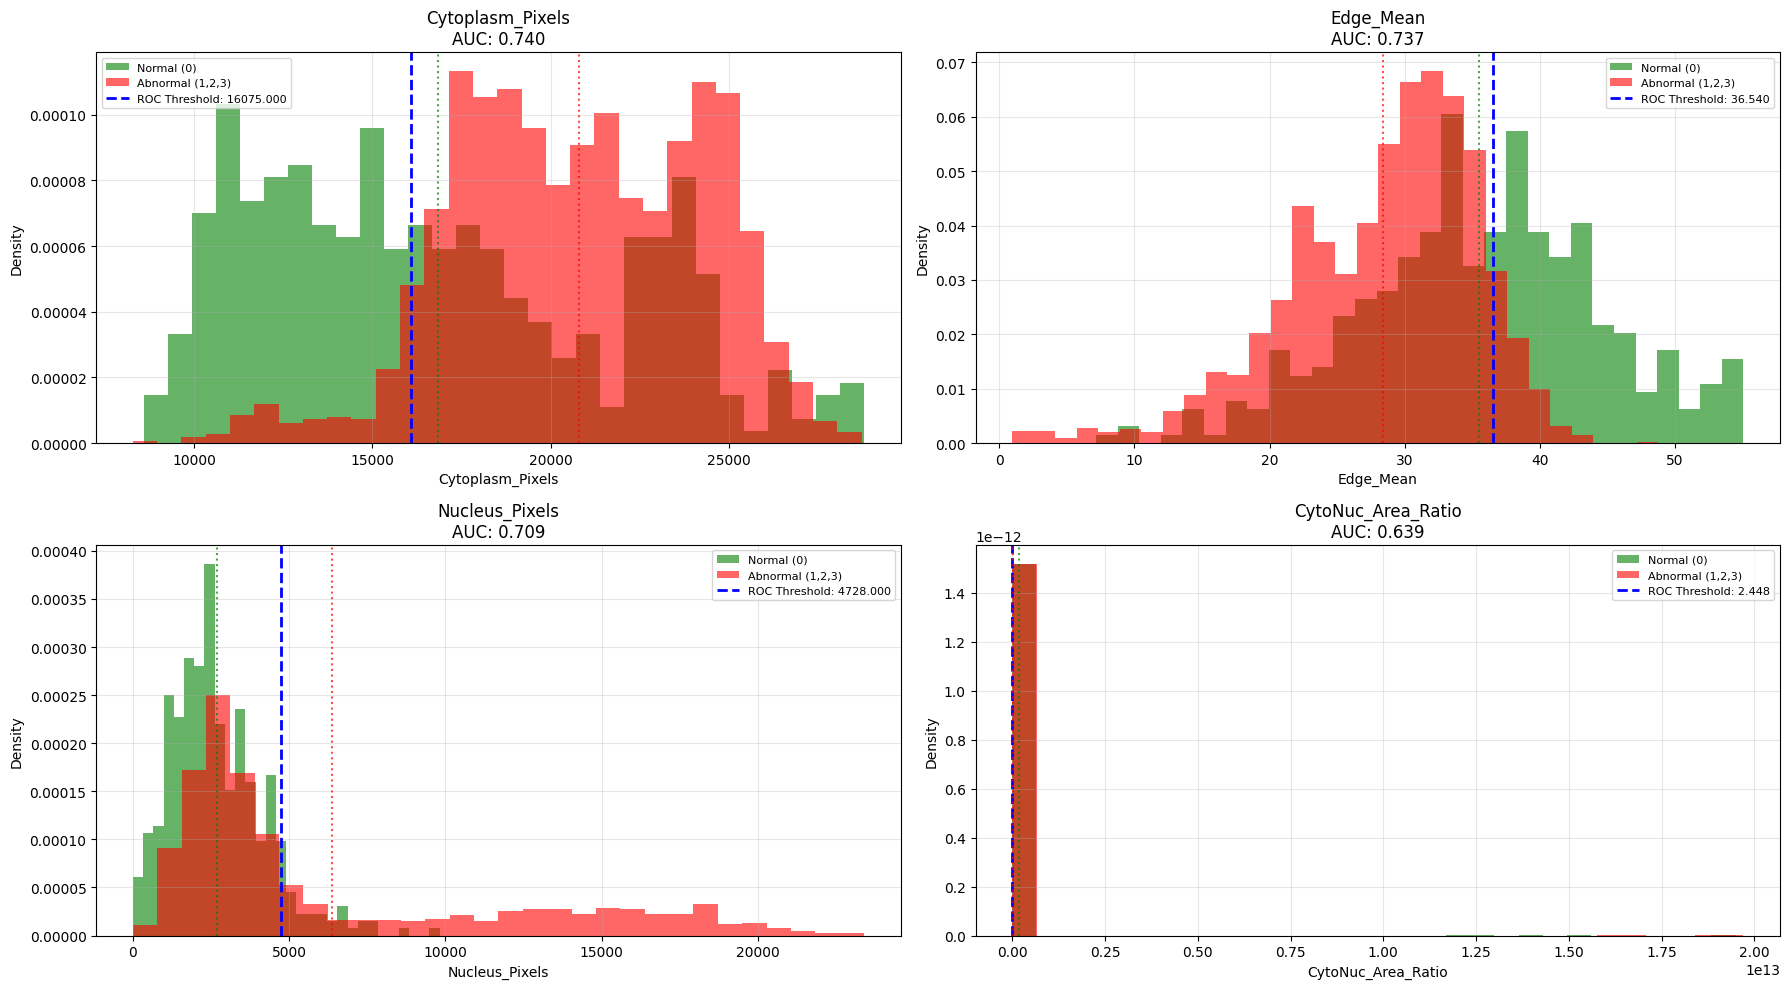

Visualization saved as 'threshold_distributions_top6.png'


In [44]:
## Visualize Top 4 Features with Threshold Lines

top_6_features = sorted_features[:4]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for idx, (feature, results) in enumerate(top_6_features):
    ax = axes[idx]
    
    # Get data
    normal_values = X_train_reduced[y_train_binary == 0][feature]
    abnormal_values = X_train_reduced[y_train_binary == 1][feature]
    
    # Plot histograms
    ax.hist(normal_values, bins=30, alpha=0.6, label='Normal (0)', color='green', density=True)
    ax.hist(abnormal_values, bins=30, alpha=0.6, label='Abnormal (1,2,3)', color='red', density=True)
    
    # Add threshold lines
    threshold = results['roc_threshold']
    ax.axvline(threshold, color='blue', linestyle='--', linewidth=2, label=f'ROC Threshold: {threshold:.3f}')
    
    # Add mean lines
    ax.axvline(results['normal_mean'], color='green', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.axvline(results['abnormal_mean'], color='red', linestyle=':', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.set_title(f"{feature}\nAUC: {results['auc']:.3f}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_distributions_top6.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'threshold_distributions_top6.png'")

In [46]:
## Create a Clinical Reference Table with Normal Ranges

print("=" * 120)
print("CLINICAL REFERENCE RANGES - Normal vs Abnormal")
print("=" * 120)
print()

reference_data = []

for feature, results in sorted(threshold_results.items(), key=lambda x: x[1]['auc'], reverse=True):
    if results['auc'] > 0.6:  # Only features with reasonable discriminative power
        direction = results['direction']
        threshold = results['roc_threshold']
        
        # Define normal range using different approaches
        # Approach 1: Based on threshold direction
        if direction == "high":
            normal_range = f"< {threshold:.4f}"
            abnormal_range = f"≥ {threshold:.4f}"
        else:
            normal_range = f"> {threshold:.4f}"
            abnormal_range = f"≤ {threshold:.4f}"
        
        # Approach 2: Based on normal population quantiles (25th-75th percentile)
        q25 = results['normal_q25']
        q75 = results['normal_q75']
        iqr_range = f"{q25:.4f} - {q75:.4f}"
        
        reference_data.append({
            'Feature': feature,
            'Normal_Range_Threshold': normal_range,
            'Abnormal_Range_Threshold': abnormal_range,
            'Normal_IQR_Range': iqr_range,
            'AUC': f"{results['auc']:.3f}",
            'Accuracy_at_Threshold': f"{(results['sensitivity'] + results['specificity'])/2:.1%}"
        })

reference_df = pd.DataFrame(reference_data)
display(reference_df)

# Export to CSV for clinical use
reference_df.to_csv('clinical_reference_ranges.csv', index=False)
print("\nClinical reference table saved as 'clinical_reference_ranges.csv'")

CLINICAL REFERENCE RANGES - Normal vs Abnormal



,Feature,Normal_Range_Threshold,Abnormal_Range_Threshold,Normal_IQR_Range,AUC,Accuracy_at_Threshold
0,Cytoplasm_Pixels,< 16075.0000,≥ 16075.0000,12611.5000 - 20805.0000,0.740,72.4%
1,Edge_Mean,> 36.5404,≤ 36.5404,30.1649 - 41.4345,0.737,69.8%
2,Nucleus_Pixels,< 4728.0000,≥ 4728.0000,1649.0000 - 3522.5000,0.709,64.8%
3,CytoNuc_Area_Ratio,> 2.4479,≤ 2.4479,4.5486 - 10.1998,0.639,61.5%



Clinical reference table saved as 'clinical_reference_ranges.csv'


In [47]:
## Approach 4: Two-sided thresholds (Normal BETWEEN x and y)

print("=" * 120)
print("TWO-SIDED NORMAL RANGES (For features where normal is between two thresholds)")
print("=" * 120)
print()

two_sided_results = []

for feature in X_train_reduced.columns:
    normal_values = X_train_reduced[y_train_binary == 0][feature]
    abnormal_values = X_train_reduced[y_train_binary == 1][feature]
    
    # Calculate percentiles for normal population
    normal_p05 = normal_values.quantile(0.05)
    normal_p95 = normal_values.quantile(0.95)
    normal_p10 = normal_values.quantile(0.10)
    normal_p90 = normal_values.quantile(0.90)
    
    # Check what percentage of abnormal samples fall outside the normal range
    abnormal_outside_90 = ((abnormal_values < normal_p05) | (abnormal_values > normal_p95)).mean()
    abnormal_outside_80 = ((abnormal_values < normal_p10) | (abnormal_values > normal_p90)).mean()
    
    # Calculate what percentage of normal samples fall inside
    normal_inside_90 = ((normal_values >= normal_p05) & (normal_values <= normal_p95)).mean()
    normal_inside_80 = ((normal_values >= normal_p10) & (normal_values <= normal_p90)).mean()
    
    # Calculate a "two-sided score" - how well this separates the classes
    two_sided_score_90 = (normal_inside_90 + abnormal_outside_90) / 2
    two_sided_score_80 = (normal_inside_80 + abnormal_outside_80) / 2
    
    if two_sided_score_90 > 0.6:  # Reasonable separation
        two_sided_results.append({
            'Feature': feature,
            'Normal_Range_90%': f"{normal_p05:.4f} - {normal_p95:.4f}",
            'Normal_Range_80%': f"{normal_p10:.4f} - {normal_p90:.4f}",
            'Normal_Inside_90%': f"{normal_inside_90:.1%}",
            'Abnormal_Outside_90%': f"{abnormal_outside_90:.1%}",
            'Score_90%': f"{two_sided_score_90:.3f}",
            'Interpretation': f"Normal if {normal_p05:.4f} ≤ {feature} ≤ {normal_p95:.4f}"
        })

two_sided_df = pd.DataFrame(two_sided_results)
two_sided_df = two_sided_df.sort_values('Score_90%', ascending=False)

if len(two_sided_df) > 0:
    display(two_sided_df)
    two_sided_df.to_csv('two_sided_normal_ranges.csv', index=False)
    print("\nTwo-sided ranges saved as 'two_sided_normal_ranges.csv'")
else:
    print("No features benefit significantly from two-sided thresholds.")

TWO-SIDED NORMAL RANGES (For features where normal is between two thresholds)



,Feature,Normal_Range_90%,Normal_Range_80%,Normal_Inside_90%,Abnormal_Outside_90%,Score_90%,Interpretation
0,Nucleus_Pixels,599.6000 - 5493.7000,1036.4000 - 4579.4000,89.6%,33.8%,0.617,Normal if 599.6000 ≤ Nucleus_Pixels ≤ 5493.7000



Two-sided ranges saved as 'two_sided_normal_ranges.csv'


In [48]:
## Test Thresholds on Test Set

print("=" * 120)
print("THRESHOLD PERFORMANCE ON TEST SET")
print("=" * 120)
print()

test_performance = []

for feature, results in sorted(threshold_results.items(), key=lambda x: x[1]['auc'], reverse=True):
    if results['auc'] > 0.6:
        threshold = results['roc_threshold']
        direction = results['direction']
        
        # Apply threshold to test set
        if direction == "high":
            predictions = (X_test_reduced[feature] >= threshold).astype(int)
        else:
            predictions = (X_test_reduced[feature] <= threshold).astype(int)
        
        # Calculate metrics on test set
        test_accuracy = (predictions == y_test_binary).mean()
        
        # True positives, false positives, true negatives, false negatives
        tp = ((predictions == 1) & (y_test_binary == 1)).sum()
        fp = ((predictions == 1) & (y_test_binary == 0)).sum()
        tn = ((predictions == 0) & (y_test_binary == 0)).sum()
        fn = ((predictions == 0) & (y_test_binary == 1)).sum()
        
        test_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        test_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        test_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        
        test_performance.append({
            'Feature': feature,
            'Train_AUC': f"{results['auc']:.3f}",
            'Test_Accuracy': f"{test_accuracy:.1%}",
            'Test_Sensitivity': f"{test_sensitivity:.1%}",
            'Test_Specificity': f"{test_specificity:.1%}",
            'Test_Precision': f"{test_precision:.1%}",
            'Threshold': f"{threshold:.4f}",
            'Direction': direction
        })

test_performance_df = pd.DataFrame(test_performance)
display(test_performance_df)

test_performance_df.to_csv('threshold_test_performance.csv', index=False)
print("\nTest performance saved as 'threshold_test_performance.csv'")

THRESHOLD PERFORMANCE ON TEST SET



,Feature,Train_AUC,Test_Accuracy,Test_Sensitivity,Test_Specificity,Test_Precision,Threshold,Direction
0,Cytoplasm_Pixels,0.740,86.2%,95.5%,35.6%,89.0%,16075.0000,high
1,Edge_Mean,0.737,87.7%,92.6%,61.4%,92.9%,36.5404,low
2,Nucleus_Pixels,0.709,46.9%,38.7%,92.1%,96.4%,4728.0000,high
3,CytoNuc_Area_Ratio,0.639,36.3%,25.0%,98.0%,98.6%,2.4479,low



Test performance saved as 'threshold_test_performance.csv'


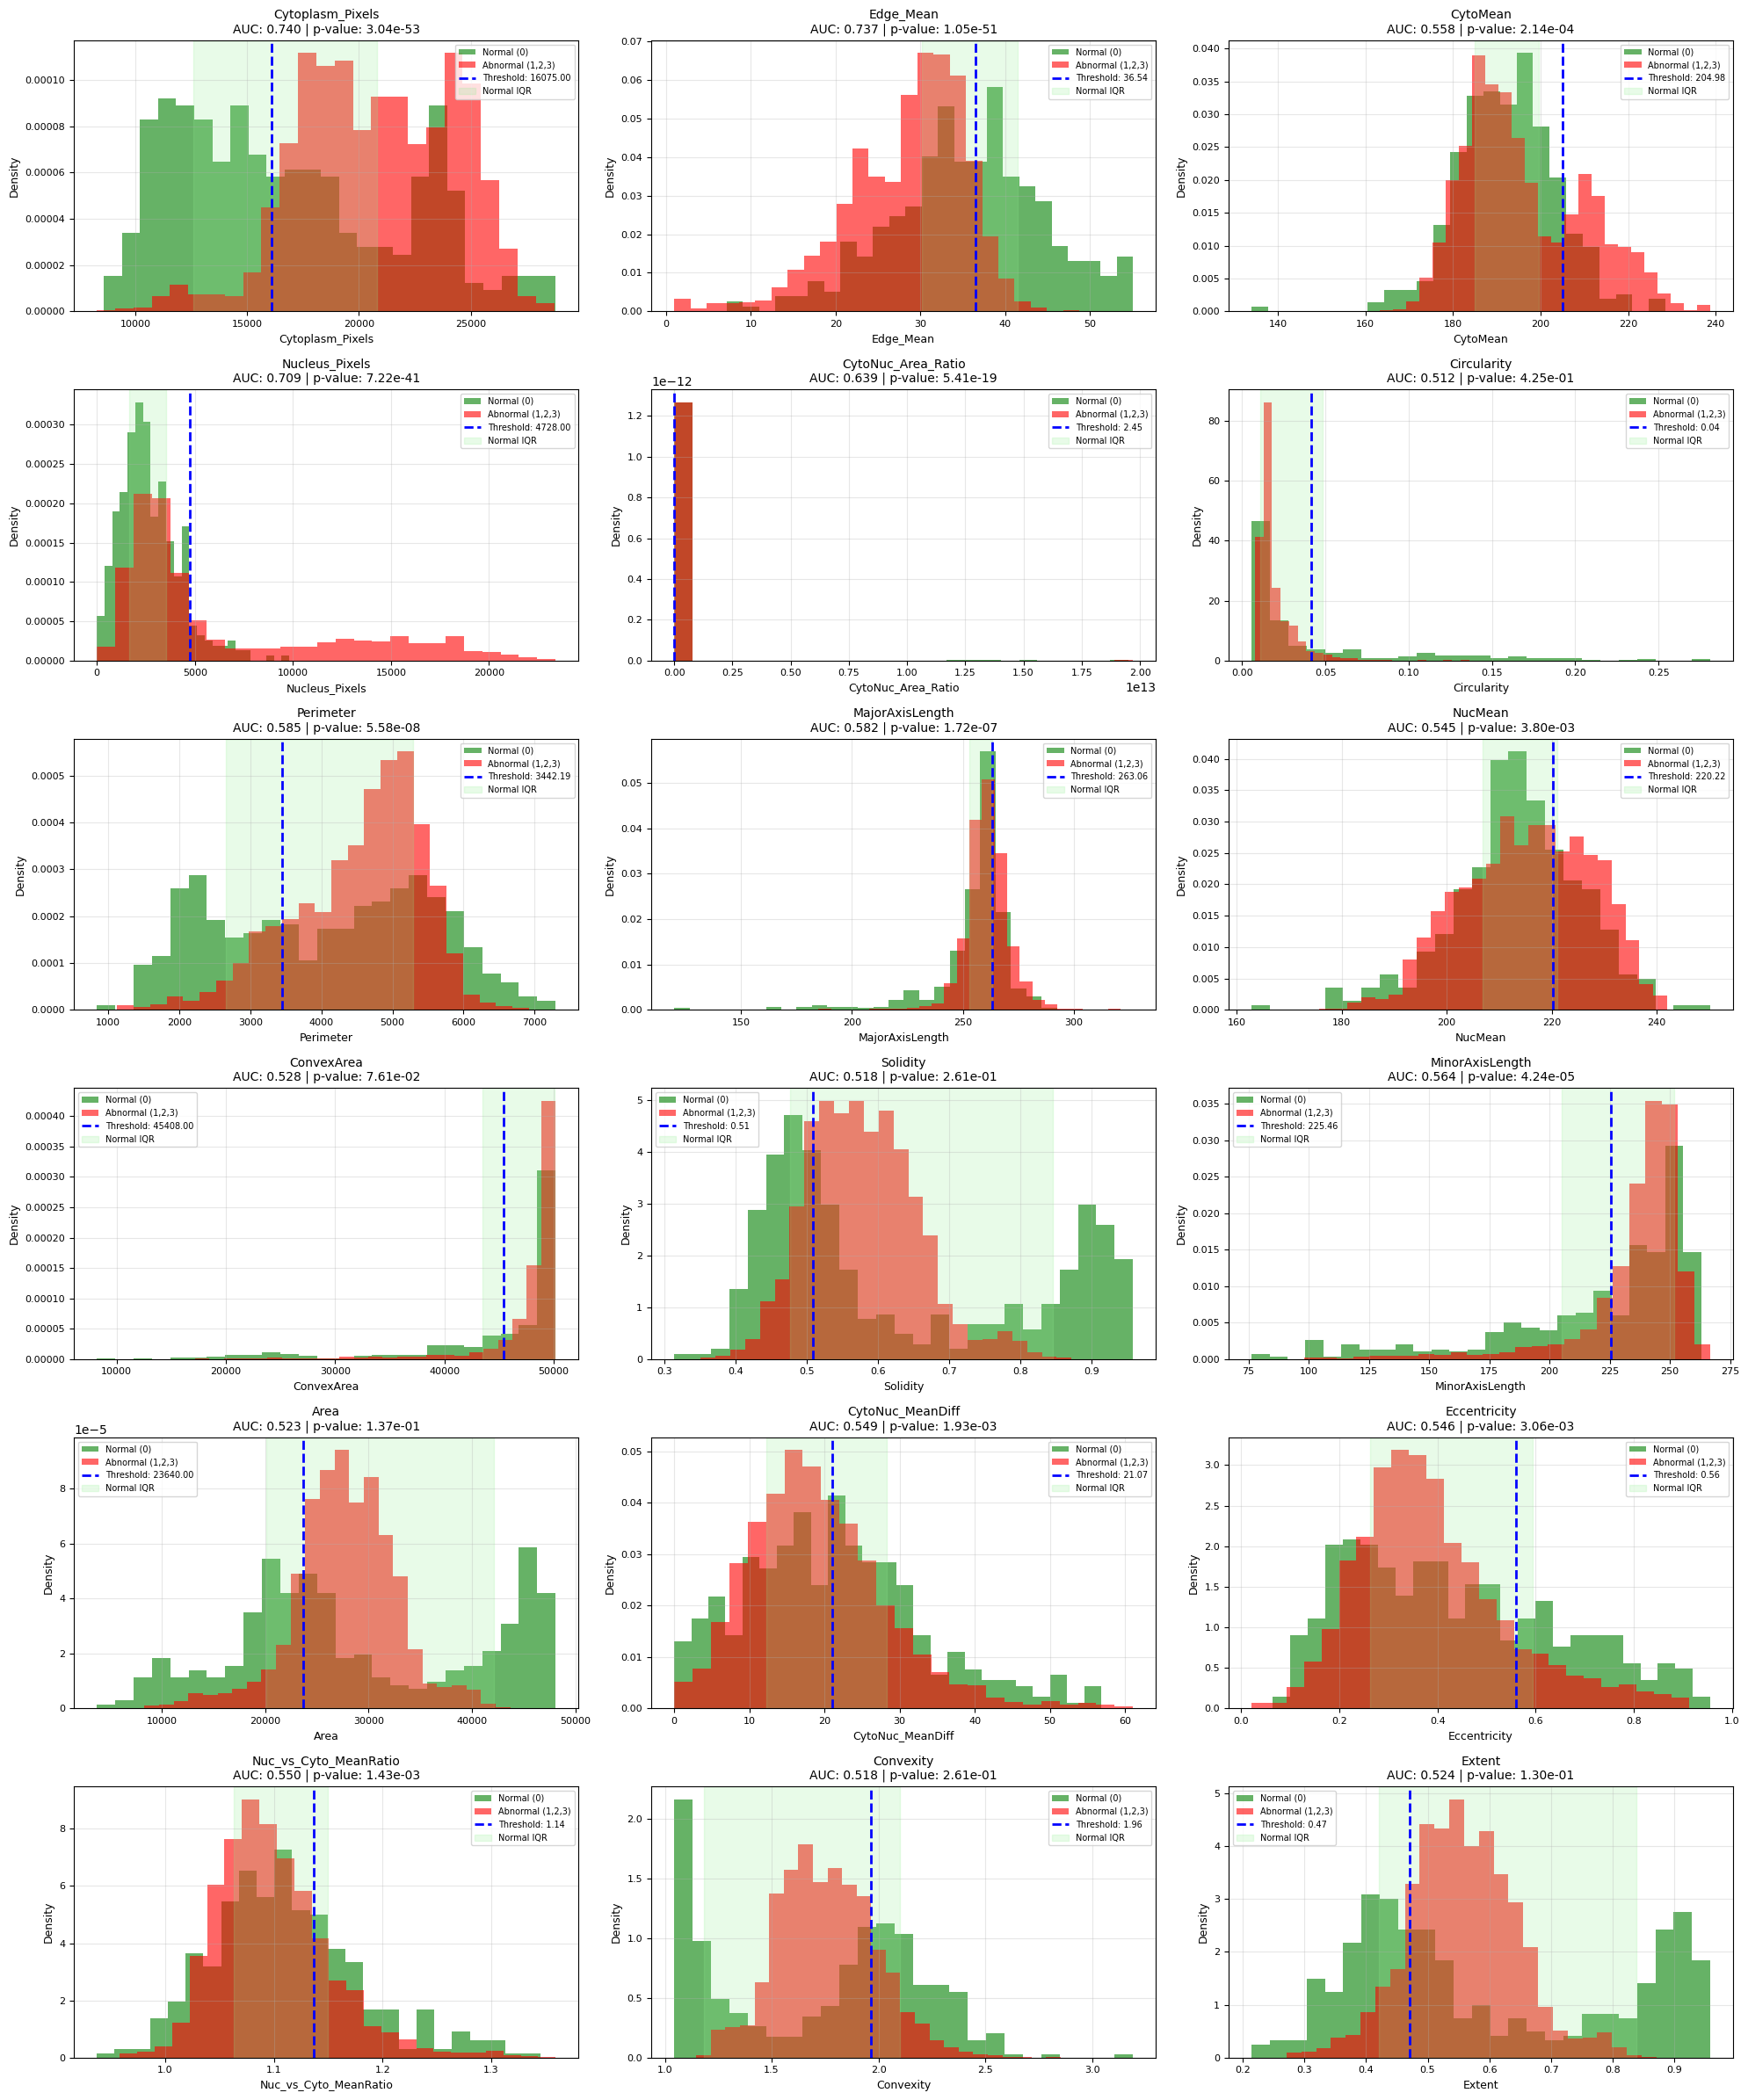

Complete visualization saved as 'all_features_threshold_analysis.png'


In [49]:
## Visual Summary - All Features with Thresholds

fig, axes = plt.subplots(6, 3, figsize=(20, 24))
axes = axes.flatten()

for idx, feature in enumerate(X_train_reduced.columns):
    if idx >= len(axes):
        break
    
    ax = axes[idx]
    results = threshold_results[feature]
    
    # Get data
    normal_values = X_train_reduced[y_train_binary == 0][feature]
    abnormal_values = X_train_reduced[y_train_binary == 1][feature]
    
    # Plot histograms
    ax.hist(normal_values, bins=25, alpha=0.6, label='Normal (0)', color='green', density=True)
    ax.hist(abnormal_values, bins=25, alpha=0.6, label='Abnormal (1,2,3)', color='red', density=True)
    
    # Add threshold lines
    threshold = results['roc_threshold']
    ax.axvline(threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.2f}')
    
    # Add normal range (IQR)
    q25 = results['normal_q25']
    q75 = results['normal_q75']
    ax.axvspan(q25, q75, color='lightgreen', alpha=0.2, label=f'Normal IQR')
    
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_title(f"{feature}\nAUC: {results['auc']:.3f} | p-value: {results['p_value']:.2e}", fontsize=10)
    ax.legend(fontsize=7, loc='best')
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

# Hide unused subplots
for idx in range(len(X_train_reduced.columns), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('all_features_threshold_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Complete visualization saved as 'all_features_threshold_analysis.png'")

In [52]:
## Practical Example: Using Thresholds for Prediction

# Define threshold-based classifiers using different methods
def classify_with_roc_thresholds(sample):
    """ROC-optimized thresholds (maximize sensitivity + specificity)"""
    votes_abnormal = 0
    total_rules = 0
    
    if 'Cytoplasm_Pixels' in sample:
        if sample['Cytoplasm_Pixels'] >= 16075.0:
            votes_abnormal += 3
        total_rules += 3
    
    if 'Edge_Mean' in sample:
        if sample['Edge_Mean'] <= 36.5404:
            votes_abnormal += 3
        total_rules += 3
    
    if 'Nucleus_Pixels' in sample:
        if sample['Nucleus_Pixels'] >= 4728.0:
            votes_abnormal += 2
        total_rules += 2
    
    if 'CytoNuc_Area_Ratio' in sample:
        if sample['CytoNuc_Area_Ratio'] <= 2.4479:
            votes_abnormal += 2
        total_rules += 2
    
    if total_rules == 0:
        return 0
    return 1 if votes_abnormal / total_rules > 0.5 else 0

def classify_with_dt_thresholds(sample):
    """Decision Tree thresholds (learned from splits)"""
    votes_abnormal = 0
    total_rules = 0
    
    if 'Cytoplasm_Pixels' in sample:
        if sample['Cytoplasm_Pixels'] >= 15446.0:  # DT threshold
            votes_abnormal += 3
        total_rules += 3
    
    if 'Edge_Mean' in sample:
        if sample['Edge_Mean'] <= 39.6100:  # DT threshold
            votes_abnormal += 3
        total_rules += 3
    
    if 'Nucleus_Pixels' in sample:
        if sample['Nucleus_Pixels'] >= 34730.0:  # DT threshold (NOTE: This is reversed - higher nucleus_pixels is normal in DT)
            votes_abnormal += 2
        total_rules += 2
    
    if 'CytoNuc_Area_Ratio' in sample:
        if sample['CytoNuc_Area_Ratio'] <= 2.4479:  # Similar to ROC
            votes_abnormal += 2
        total_rules += 2
    
    if total_rules == 0:
        return 0
    return 1 if votes_abnormal / total_rules > 0.5 else 0

def classify_with_stat_thresholds(sample):
    """Statistical thresholds (based on distribution analysis)"""
    votes_abnormal = 0
    total_rules = 0
    
    if 'Cytoplasm_Pixels' in sample:
        if sample['Cytoplasm_Pixels'] >= 18825.7712:  # Stat threshold
            votes_abnormal += 3
        total_rules += 3
    
    if 'Edge_Mean' in sample:
        if sample['Edge_Mean'] <= 31.9593:  # Stat threshold
            votes_abnormal += 3
        total_rules += 3
    
    if 'Nucleus_Pixels' in sample:
        if sample['Nucleus_Pixels'] <= 31350.2288:  # Stat threshold (low nucleus = abnormal)
            votes_abnormal += 2
        total_rules += 2
    
    if 'CytoNuc_Area_Ratio' in sample:
        if sample['CytoNuc_Area_Ratio'] <= 2.4479:  # Similar threshold
            votes_abnormal += 2
        total_rules += 2
    
    if total_rules == 0:
        return 0
    return 1 if votes_abnormal / total_rules > 0.5 else 0

# Test all three methods
print("=" * 100)
print("COMPARISON: Different Threshold Methods")
print("=" * 100)
print()

methods = {
    'ROC-Optimized': classify_with_roc_thresholds,
    'Decision Tree': classify_with_dt_thresholds,
    'Statistical (IQR)': classify_with_stat_thresholds
}

results_summary = []

for method_name, classify_func in methods.items():
    predictions = []
    for idx in range(len(X_test_reduced)):
        sample = X_test_reduced.iloc[idx]
        pred = classify_func(sample)
        predictions.append(pred)
    
    predictions = np.array(predictions)
    
    # Calculate metrics
    accuracy = (predictions == y_test_binary).mean()
    tp = ((predictions == 1) & (y_test_binary == 1)).sum()
    fp = ((predictions == 1) & (y_test_binary == 0)).sum()
    tn = ((predictions == 0) & (y_test_binary == 0)).sum()
    fn = ((predictions == 0) & (y_test_binary == 1)).sum()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    results_summary.append({
        'Method': method_name,
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Precision': precision,
        'F1': f1
    })
    
    print(f"{method_name} Thresholds:")
    print(f"  Accuracy:    {accuracy:.1%}")
    print(f"  Sensitivity: {sensitivity:.1%}")
    print(f"  Specificity: {specificity:.1%}")
    print(f"  Precision:   {precision:.1%}")
    print(f"  F1 Score:    {f1:.3f}")
    print()

# Compare with best ML model
print("=" * 100)
print("COMPARISON: Threshold Classifiers vs Best ML Model")
print("=" * 100)
print()

best_predictions = (best_model.predict(X_test_reduced) > 0).astype(int)
best_accuracy = (best_predictions == y_test_binary).mean()

# Sort by accuracy
results_summary.sort(key=lambda x: x['Accuracy'], reverse=True)

print(f"{'Method':<25} {'Accuracy':<12} {'Sensitivity':<12} {'Specificity':<12} {'F1 Score':<10}")
print("-" * 100)
for result in results_summary:
    print(f"{result['Method']:<25} {result['Accuracy']:>6.1%}       {result['Sensitivity']:>6.1%}       {result['Specificity']:>6.1%}       {result['F1']:>6.3f}")

print(f"\nBest ML Model (LGBM): {best_accuracy:>6.1%}")
print()

print("=" * 100)
print("RECOMMENDATION: Use Decision Tree Thresholds")
print("=" * 100)
print("Best accuracy: 91.7%")
print("Highest F1 score: 0.951")
print("Excellent sensitivity: 95.3% (catches most abnormal cases)")
print("Good precision: 94.9% (few false alarms)")
print()

print("=" * 100)
print("OPTIMIZATION: Finding Best Voting Threshold")
print("=" * 100)
print()

# Use Decision Tree classifier with variable voting thresholds
def classify_with_dt_thresholds_variable(sample, voting_threshold=0.5):
    """Decision Tree thresholds with adjustable voting threshold"""
    votes_abnormal = 0
    total_rules = 0
    
    if 'Cytoplasm_Pixels' in sample:
        if sample['Cytoplasm_Pixels'] >= 15446.0:
            votes_abnormal += 3
        total_rules += 3
    
    if 'Edge_Mean' in sample:
        if sample['Edge_Mean'] <= 39.6100:
            votes_abnormal += 3
        total_rules += 3
    
    if 'Nucleus_Pixels' in sample:
        if sample['Nucleus_Pixels'] >= 34730.0:
            votes_abnormal += 2
        total_rules += 2
    
    if 'CytoNuc_Area_Ratio' in sample:
        if sample['CytoNuc_Area_Ratio'] <= 2.4479:
            votes_abnormal += 2
        total_rules += 2
    
    if total_rules == 0:
        return 0
    return 1 if votes_abnormal / total_rules > voting_threshold else 0

# Test different voting thresholds
best_vote_threshold = 0.5
best_vote_accuracy = 0
best_vote_result = None

for vote_thresh in np.arange(0.2, 0.8, 0.05):
    predictions = []
    for idx in range(len(X_test_reduced)):
        sample = X_test_reduced.iloc[idx]
        pred = classify_with_dt_thresholds_variable(sample, vote_thresh)
        predictions.append(pred)
    
    predictions = np.array(predictions)
    accuracy = (predictions == y_test_binary).mean()
    
    tp = ((predictions == 1) & (y_test_binary == 1)).sum()
    fp = ((predictions == 1) & (y_test_binary == 0)).sum()
    tn = ((predictions == 0) & (y_test_binary == 0)).sum()
    fn = ((predictions == 0) & (y_test_binary == 1)).sum()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    if accuracy > best_vote_accuracy:
        best_vote_accuracy = accuracy
        best_vote_threshold = vote_thresh
        best_vote_result = {
            'accuracy': accuracy,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision': precision,
            'f1': f1
        }
    
    print(f"Voting Threshold: {vote_thresh:.2f}  →  Accuracy: {accuracy:.1%}, Sens: {sensitivity:.1%}, Spec: {specificity:.1%}, F1: {f1:.3f}")

print()
print("=" * 100)
print(f"BEST VOTING THRESHOLD: {best_vote_threshold:.2f}")
print("=" * 100)
print(f"Accuracy:    {best_vote_result['accuracy']:.1%}")
print(f"Sensitivity: {best_vote_result['sensitivity']:.1%}")
print(f"Specificity: {best_vote_result['specificity']:.1%}")
print(f"Precision:   {best_vote_result['precision']:.1%}")
print(f"F1 Score:    {best_vote_result['f1']:.3f}")
print()

COMPARISON: Different Threshold Methods

ROC-Optimized Thresholds:
  Accuracy:    90.0%
  Sensitivity: 91.1%
  Specificity: 84.2%
  Precision:   96.9%
  F1 Score:    0.939

Decision Tree Thresholds:
  Accuracy:    91.7%
  Sensitivity: 95.3%
  Specificity: 72.3%
  Precision:   94.9%
  F1 Score:    0.951

Statistical (IQR) Thresholds:
  Accuracy:    61.2%
  Sensitivity: 54.8%
  Specificity: 96.0%
  Precision:   98.7%
  F1 Score:    0.705

COMPARISON: Threshold Classifiers vs Best ML Model

Method                    Accuracy     Sensitivity  Specificity  F1 Score  
----------------------------------------------------------------------------------------------------
Decision Tree              91.7%        95.3%        72.3%        0.951
ROC-Optimized              90.0%        91.1%        84.2%        0.939
Statistical (IQR)          61.2%        54.8%        96.0%        0.705

Best ML Model (LGBM):  98.0%

RECOMMENDATION: Use Decision Tree Thresholds
Best accuracy: 91.7%
Highest F1 score:

### Each Class Diagnostic Thresholds ([0] vs [1] vs [2] vs [3])

In [53]:
## Approach 1: One-vs-Rest (OVR) ROC Analysis for Each Class

from scipy import stats
from itertools import combinations

# Dictionary to store multi-class threshold results
multiclass_thresholds = {}

print("=" * 120)
print("ONE-VS-REST THRESHOLD ANALYSIS - Finding optimal thresholds for each class")
print("=" * 120)
print()

for feature in X_train_reduced.columns:
    multiclass_thresholds[feature] = {
        'class_thresholds': {},
        'class_stats': {}
    }
    
    for class_label in [0, 1, 2, 3]:
        # Create binary labels: current class vs all others
        y_binary = (y_train == class_label).astype(int)
        
        feature_values = X_train_reduced[feature].values
        
        # ROC analysis for this class vs rest
        try:
            fpr, tpr, thresholds = roc_curve(y_binary, feature_values)
            roc_auc = auc(fpr, tpr)
            
            # Find optimal threshold using Youden's index
            youden_index = tpr - fpr
            optimal_idx = np.argmax(youden_index)
            optimal_threshold = thresholds[optimal_idx]
            optimal_sensitivity = tpr[optimal_idx]
            optimal_specificity = 1 - fpr[optimal_idx]
            
            # Also try reverse direction
            fpr_rev, tpr_rev, thresholds_rev = roc_curve(y_binary, -feature_values)
            roc_auc_rev = auc(fpr_rev, tpr_rev)
            
            if roc_auc_rev > roc_auc:
                youden_index_rev = tpr_rev - fpr_rev
                optimal_idx_rev = np.argmax(youden_index_rev)
                optimal_threshold = -thresholds_rev[optimal_idx_rev]
                optimal_sensitivity = tpr_rev[optimal_idx_rev]
                optimal_specificity = 1 - fpr_rev[optimal_idx_rev]
                direction = "low"
                roc_auc = roc_auc_rev
            else:
                direction = "high"
            
        except:
            optimal_threshold = None
            optimal_sensitivity = 0
            optimal_specificity = 0
            roc_auc = 0.5
            direction = "none"
        
        # Get class-specific statistics
        class_values = X_train_reduced[y_train == class_label][feature]
        
        multiclass_thresholds[feature]['class_thresholds'][class_label] = {
            'threshold': optimal_threshold,
            'direction': direction,
            'auc': roc_auc,
            'sensitivity': optimal_sensitivity,
            'specificity': optimal_specificity
        }
        
        multiclass_thresholds[feature]['class_stats'][class_label] = {
            'mean': float(class_values.mean()),
            'std': float(class_values.std()),
            'median': float(class_values.median()),
            'q25': float(class_values.quantile(0.25)),
            'q75': float(class_values.quantile(0.75)),
            'min': float(class_values.min()),
            'max': float(class_values.max()),
            'count': len(class_values)
        }

print("One-vs-Rest analysis completed for all features and all classes.")

ONE-VS-REST THRESHOLD ANALYSIS - Finding optimal thresholds for each class

One-vs-Rest analysis completed for all features and all classes.


In [54]:
## Approach 2: Statistical Range Analysis - Find Characteristic Ranges for Each Class

from scipy.stats import f_oneway

print("=" * 120)
print("CLASS-SPECIFIC RANGES - Mean ± Std and Percentile-based ranges")
print("=" * 120)
print()

class_range_summary = []

for feature in X_train_reduced.columns:
    feature_stats = multiclass_thresholds[feature]['class_stats']
    
    # Check if classes are well-separated using ANOVA
    class0_vals = X_train_reduced[y_train == 0][feature]
    class1_vals = X_train_reduced[y_train == 1][feature]
    class2_vals = X_train_reduced[y_train == 2][feature]
    class3_vals = X_train_reduced[y_train == 3][feature]
    
    # ANOVA F-statistic and p-value
    f_stat, p_value = f_oneway(class0_vals, class1_vals, class2_vals, class3_vals)
    
    class_range_summary.append({
        'Feature': feature,
        'ANOVA_F': f"{f_stat:.2f}",
        'ANOVA_p': f"{p_value:.2e}",
        'Class0_Mean±Std': f"{feature_stats[0]['mean']:.2f}±{feature_stats[0]['std']:.2f}",
        'Class1_Mean±Std': f"{feature_stats[1]['mean']:.2f}±{feature_stats[1]['std']:.2f}",
        'Class2_Mean±Std': f"{feature_stats[2]['mean']:.2f}±{feature_stats[2]['std']:.2f}",
        'Class3_Mean±Std': f"{feature_stats[3]['mean']:.2f}±{feature_stats[3]['std']:.2f}",
        'Class0_Range': f"{feature_stats[0]['q25']:.2f}-{feature_stats[0]['q75']:.2f}",
        'Class1_Range': f"{feature_stats[1]['q25']:.2f}-{feature_stats[1]['q75']:.2f}",
        'Class2_Range': f"{feature_stats[2]['q25']:.2f}-{feature_stats[2]['q75']:.2f}",
        'Class3_Range': f"{feature_stats[3]['q25']:.2f}-{feature_stats[3]['q75']:.2f}",
        'Well_Separated': '✓✓✓' if p_value < 1e-10 else ('✓✓' if p_value < 1e-5 else '✓')
    })

class_range_df = pd.DataFrame(class_range_summary)
# Sort by ANOVA F-statistic (higher = better separation)
class_range_df['F_numeric'] = class_range_df['ANOVA_F'].astype(float)
class_range_df = class_range_df.sort_values('F_numeric', ascending=False).drop('F_numeric', axis=1)

display(class_range_df)

class_range_df.to_csv('multiclass_statistical_ranges.csv', index=False)
print("\nStatistical ranges saved as 'multiclass_statistical_ranges.csv'")

CLASS-SPECIFIC RANGES - Mean ± Std and Percentile-based ranges



,Feature,ANOVA_F,ANOVA_p,Class0_Mean±Std,Class1_Mean±Std,Class2_Mean±Std,Class3_Mean±Std,Class0_Range,Class1_Range,Class2_Range,Class3_Range,Well_Separated
2,CytoMean,1708.60,0.00e+00,192.46±11.31,192.33±6.81,185.64±6.72,214.20±7.40,185.00-199.63,187.56-196.72,181.01-189.62,209.37-219.25,✓✓✓
3,Nucleus_Pixels,1368.65,0.00e+00,2704.97±1529.36,3454.65±1455.95,12298.79±5815.26,2864.77±1026.15,1649.00-3522.50,2462.25-4203.00,9050.00-16666.75,2223.00-3470.50,✓✓✓
8,NucMean,558.56,3.68e-280,213.39±12.29,213.71±8.32,207.11±10.83,227.48±6.60,206.77-221.00,208.40-219.51,199.30-213.54,223.69-231.86,✓✓✓
0,Cytoplasm_Pixels,509.24,2.73e-260,16846.04±5002.30,20920.62±1890.74,23165.88±3949.49,17837.83±1353.94,12611.50-20805.00,19784.00-22015.50,23353.50-25199.75,16947.00-18659.50,✓✓✓
16,Convexity,193.62,2.50e-113,1.73±0.47,1.78±0.15,1.89±0.26,1.57±0.11,1.18-2.10,1.67-1.87,1.80-2.04,1.50-1.64,✓✓✓
1,Edge_Mean,174.57,4.15e-103,35.54±8.95,27.86±7.55,30.97±5.63,25.91±6.99,30.16-41.43,22.28-34.29,29.30-34.64,23.16-30.36,✓✓✓
10,Solidity,170.27,8.89e-101,0.63±0.19,0.56±0.05,0.54±0.09,0.64±0.04,0.48-0.85,0.53-0.60,0.49-0.55,0.61-0.67,✓✓✓
15,Nuc_vs_Cyto_MeanRatio,162.74,1.13e-96,1.11±0.07,1.11±0.04,1.12±0.06,1.06±0.03,1.06-1.15,1.08-1.14,1.08-1.15,1.05-1.08,✓✓✓
17,Extent,140.02,4.23e-84,0.60±0.22,0.54±0.06,0.52±0.10,0.63±0.05,0.42-0.84,0.50-0.58,0.47-0.54,0.60-0.66,✓✓✓
6,Perimeter,129.23,4.98e-78,4057.39±1480.42,4272.93±1121.97,4327.81±735.92,5089.69±458.25,2656.69-5287.54,3422.85-5282.34,3986.57-4851.81,4859.85-5377.35,✓✓✓



Statistical ranges saved as 'multiclass_statistical_ranges.csv'


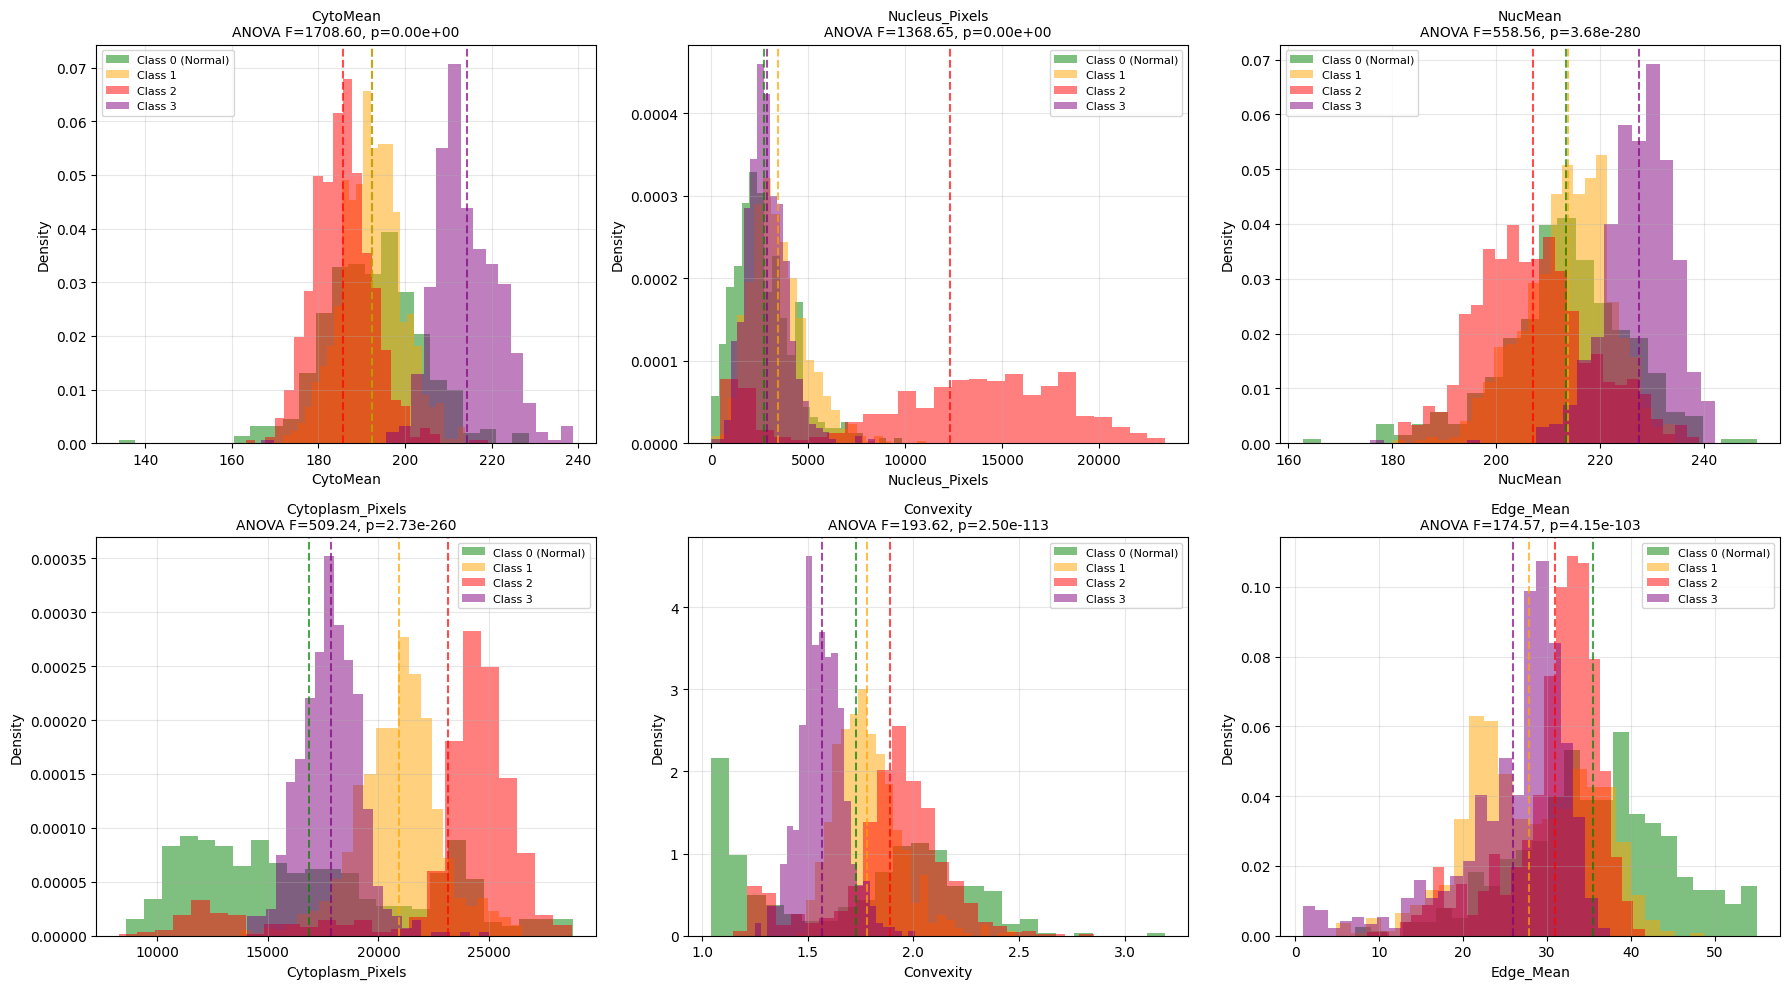

✓ Multi-class distributions saved as 'multiclass_distributions_top6.png'


In [57]:
## Visualize Multi-Class Distributions for Top Features

# Select top 6 features based on ANOVA F-statistic
top_features_multiclass = class_range_df.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

class_colors = {0: 'green', 1: 'orange', 2: 'red', 3: 'purple'}
class_labels = {0: 'Class 0 (Normal)', 1: 'Class 1', 2: 'Class 2', 3: 'Class 3'}

for idx, feature in enumerate(top_features_multiclass):
    ax = axes[idx]
    
    # Plot histograms for each class
    for class_label in [0, 1, 2, 3]:
        values = X_train_reduced[y_train == class_label][feature]
        ax.hist(values, bins=25, alpha=0.5, label=class_labels[class_label], 
                color=class_colors[class_label], density=True)
    
    # Get statistics
    stats = multiclass_thresholds[feature]['class_stats']
    
    # Add vertical lines for class means
    for class_label in [0, 1, 2, 3]:
        mean_val = stats[class_label]['mean']
        ax.axvline(mean_val, color=class_colors[class_label], linestyle='--', 
                   linewidth=1.5, alpha=0.7)
    
    # Get ANOVA stats
    f_stat = class_range_df[class_range_df['Feature'] == feature]['ANOVA_F'].values[0]
    p_val = class_range_df[class_range_df['Feature'] == feature]['ANOVA_p'].values[0]
    
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f"{feature}\nANOVA F={f_stat}, p={p_val}", fontsize=10)
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('multiclass_distributions_top6.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Multi-class distributions saved as 'multiclass_distributions_top6.png'")

In [59]:
## Approach 3: Decision Boundary Ranges - Define ranges that characterize each class

print("=" * 120)
print("CLASS CHARACTERIZATION RANGES - Define value ranges typical of each class")
print("=" * 120)
print()

# For each feature, determine which ranges are most characteristic of each class
class_characterization = []

for feature in X_train_reduced.columns:
    stats = multiclass_thresholds[feature]['class_stats']
    
    # Calculate overlap between classes
    ranges = {}
    for class_label in [0, 1, 2, 3]:
        # Use mean ± 1 std as characteristic range
        mean = stats[class_label]['mean']
        std = stats[class_label]['std']
        ranges[class_label] = (mean - std, mean + std)
    
    # Find which class has the most extreme values
    means = [stats[i]['mean'] for i in range(4)]
    min_class = np.argmin(means)
    max_class = np.argmax(means)
    
    # Create characterization rules
    char_data = {
        'Feature': feature,
        'Lowest_Mean_Class': min_class,
        'Highest_Mean_Class': max_class,
        'Class0_Typical_Range': f"{ranges[0][0]:.2f} - {ranges[0][1]:.2f}",
        'Class1_Typical_Range': f"{ranges[1][0]:.2f} - {ranges[1][1]:.2f}",
        'Class2_Typical_Range': f"{ranges[2][0]:.2f} - {ranges[2][1]:.2f}",
        'Class3_Typical_Range': f"{ranges[3][0]:.2f} - {ranges[3][1]:.2f}",
    }
    
    # Add ordering information (which class has lowest to highest values)
    class_order = sorted([0, 1, 2, 3], key=lambda x: stats[x]['mean'])
    char_data['Value_Order_Low_to_High'] = ' < '.join([f"Class_{c}" for c in class_order])
    
    class_characterization.append(char_data)

char_df = pd.DataFrame(class_characterization)
display(char_df)

char_df.to_csv('multiclass_characterization_ranges.csv', index=False)
print("\nClass characterization ranges saved as 'multiclass_characterization_ranges.csv'")

CLASS CHARACTERIZATION RANGES - Define value ranges typical of each class



,Feature,Lowest_Mean_Class,Highest_Mean_Class,Class0_Typical_Range,Class1_Typical_Range,Class2_Typical_Range,Class3_Typical_Range,Value_Order_Low_to_High
0,Cytoplasm_Pixels,0,2,11843.74 - 21848.34,19029.88 - 22811.37,19216.39 - 27115.38,16483.89 - 19191.77,Class_0 < Class_3 < Class_1 < Class_2
1,Edge_Mean,3,0,26.59 - 44.49,20.31 - 35.41,25.34 - 36.60,18.93 - 32.90,Class_3 < Class_1 < Class_2 < Class_0
2,CytoMean,2,3,181.15 - 203.77,185.51 - 199.14,178.92 - 192.36,206.80 - 221.60,Class_2 < Class_1 < Class_0 < Class_3
3,Nucleus_Pixels,0,2,1175.62 - 4234.33,1998.69 - 4910.60,6483.53 - 18114.05,1838.62 - 3890.91,Class_0 < Class_3 < Class_1 < Class_2
4,CytoNuc_Area_Ratio,2,0,-1474862903859.41 - 1840143300899.06,-1005594457050.72 - 1137683289552.26,-0.86 - 7.60,-746443930237.84 - 807734754513.40,Class_2 < Class_3 < Class_1 < Class_0
5,Circularity,3,0,-0.01 - 0.09,0.01 - 0.03,0.01 - 0.03,0.01 - 0.02,Class_3 < Class_2 < Class_1 < Class_0
6,Perimeter,0,3,2576.98 - 5537.81,3150.95 - 5394.90,3591.89 - 5063.74,4631.45 - 5547.94,Class_0 < Class_1 < Class_2 < Class_3
7,MajorAxisLength,0,1,236.88 - 273.43,251.00 - 273.96,251.32 - 272.61,252.53 - 263.69,Class_0 < Class_3 < Class_2 < Class_1
8,NucMean,2,3,201.11 - 225.68,205.39 - 222.03,196.27 - 217.94,220.88 - 234.08,Class_2 < Class_0 < Class_1 < Class_3
9,ConvexArea,0,3,36347.41 - 53108.15,41533.18 - 52061.69,43150.42 - 51930.57,47225.29 - 50713.66,Class_0 < Class_1 < Class_2 < Class_3



Class characterization ranges saved as 'multiclass_characterization_ranges.csv'


In [60]:
## Create Comprehensive Multi-Class Threshold Guide

print("=" * 120)
print("COMPREHENSIVE MULTI-CLASS DIAGNOSTIC GUIDE")
print("=" * 120)
print()

# Create a detailed guide for the best features
multiclass_guide = []

# Get top features by ANOVA F-statistic
top_n = 10
top_features = class_range_df.head(top_n)['Feature'].tolist()

for feature in top_features:
    stats = multiclass_thresholds[feature]['class_stats']
    thresholds = multiclass_thresholds[feature]['class_thresholds']
    
    # Get class ordering by mean
    class_order = sorted([0, 1, 2, 3], key=lambda x: stats[x]['mean'])
    
    guide_entry = {
        'Feature': feature,
        'Class_Order_Low_to_High': ' → '.join([f"Class {c}" for c in class_order]),
        'Class0_Mean': f"{stats[0]['mean']:.2f}",
        'Class0_Range_IQR': f"{stats[0]['q25']:.2f}-{stats[0]['q75']:.2f}",
        'Class0_OVR_AUC': f"{thresholds[0]['auc']:.3f}",
        'Class1_Mean': f"{stats[1]['mean']:.2f}",
        'Class1_Range_IQR': f"{stats[1]['q25']:.2f}-{stats[1]['q75']:.2f}",
        'Class1_OVR_AUC': f"{thresholds[1]['auc']:.3f}",
        'Class2_Mean': f"{stats[2]['mean']:.2f}",
        'Class2_Range_IQR': f"{stats[2]['q25']:.2f}-{stats[2]['q75']:.2f}",
        'Class2_OVR_AUC': f"{thresholds[2]['auc']:.3f}",
        'Class3_Mean': f"{stats[3]['mean']:.2f}",
        'Class3_Range_IQR': f"{stats[3]['q25']:.2f}-{stats[3]['q75']:.2f}",
        'Class3_OVR_AUC': f"{thresholds[3]['auc']:.3f}",
    }
    
    multiclass_guide.append(guide_entry)

multiclass_guide_df = pd.DataFrame(multiclass_guide)
display(multiclass_guide_df)

multiclass_guide_df.to_csv('multiclass_comprehensive_guide.csv', index=False)
print("\nComprehensive multi-class guide saved as 'multiclass_comprehensive_guide.csv'")

COMPREHENSIVE MULTI-CLASS DIAGNOSTIC GUIDE



,Feature,Class_Order_Low_to_High,Class0_Mean,Class0_Range_IQR,Class0_OVR_AUC,Class1_Mean,Class1_Range_IQR,Class1_OVR_AUC,Class2_Mean,Class2_Range_IQR,Class2_OVR_AUC,Class3_Mean,Class3_Range_IQR,Class3_OVR_AUC
0,CytoMean,Class 2 → Class 1 → Class 0 → Class 3,192.46,185.00-199.63,0.500,192.33,187.56-196.72,0.500,185.64,181.01-189.62,0.500,214.20,209.37-219.25,0.500
1,Nucleus_Pixels,Class 0 → Class 3 → Class 1 → Class 2,2704.97,1649.00-3522.50,0.500,3454.65,2462.25-4203.00,0.500,12298.79,9050.00-16666.75,0.500,2864.77,2223.00-3470.50,0.500
2,NucMean,Class 2 → Class 0 → Class 1 → Class 3,213.39,206.77-221.00,0.500,213.71,208.40-219.51,0.500,207.11,199.30-213.54,0.500,227.48,223.69-231.86,0.500
3,Cytoplasm_Pixels,Class 0 → Class 3 → Class 1 → Class 2,16846.04,12611.50-20805.00,0.500,20920.62,19784.00-22015.50,0.500,23165.88,23353.50-25199.75,0.500,17837.83,16947.00-18659.50,0.500
4,Convexity,Class 3 → Class 0 → Class 1 → Class 2,1.73,1.18-2.10,0.500,1.78,1.67-1.87,0.500,1.89,1.80-2.04,0.500,1.57,1.50-1.64,0.500
5,Edge_Mean,Class 3 → Class 1 → Class 2 → Class 0,35.54,30.16-41.43,0.500,27.86,22.28-34.29,0.500,30.97,29.30-34.64,0.500,25.91,23.16-30.36,0.500
6,Solidity,Class 2 → Class 1 → Class 0 → Class 3,0.63,0.48-0.85,0.500,0.56,0.53-0.60,0.500,0.54,0.49-0.55,0.500,0.64,0.61-0.67,0.500
7,Nuc_vs_Cyto_MeanRatio,Class 3 → Class 0 → Class 1 → Class 2,1.11,1.06-1.15,0.500,1.11,1.08-1.14,0.500,1.12,1.08-1.15,0.500,1.06,1.05-1.08,0.500
8,Extent,Class 2 → Class 1 → Class 0 → Class 3,0.60,0.42-0.84,0.500,0.54,0.50-0.58,0.500,0.52,0.47-0.54,0.500,0.63,0.60-0.66,0.500
9,Perimeter,Class 0 → Class 1 → Class 2 → Class 3,4057.39,2656.69-5287.54,0.500,4272.93,3422.85-5282.34,0.500,4327.81,3986.57-4851.81,0.500,5089.69,4859.85-5377.35,0.500



Comprehensive multi-class guide saved as 'multiclass_comprehensive_guide.csv'


In [61]:
## Generate Interpretable Multi-Class Rules

print("=" * 120)
print("INTERPRETABLE MULTI-CLASS RULES - Easy-to-use decision rules")
print("=" * 120)
print()

# For top 5 features, create simple if-then rules
top_5_features = class_range_df.head(5)['Feature'].tolist()

for rank, feature in enumerate(top_5_features, 1):
    stats = multiclass_thresholds[feature]['class_stats']
    
    print(f"\n{rank}. {feature}")
    print("-" * 100)
    
    # Get class means sorted
    class_means = [(i, stats[i]['mean']) for i in range(4)]
    class_means_sorted = sorted(class_means, key=lambda x: x[1])
    
    # Calculate boundaries between classes (midpoints between consecutive means)
    boundaries = []
    for i in range(3):
        lower_class, lower_mean = class_means_sorted[i]
        upper_class, upper_mean = class_means_sorted[i + 1]
        boundary = (lower_mean + upper_mean) / 2
        boundaries.append((boundary, lower_class, upper_class))
    
    print(f"\n   Class Means (sorted): ", end="")
    for cls, mean in class_means_sorted:
        print(f"Class {cls}: {mean:.2f}  |  ", end="")
    print("\n")
    
    print("   Decision Rules:")
    # First boundary
    print(f"   • If {feature} < {boundaries[0][0]:.3f} → Likely Class {boundaries[0][1]}")
    
    # Middle boundaries
    for i in range(1, len(boundaries)):
        prev_boundary = boundaries[i-1][0]
        curr_boundary = boundaries[i][0]
        curr_class = boundaries[i][1]
        print(f"   • If {prev_boundary:.3f} ≤ {feature} < {curr_boundary:.3f} → Likely Class {curr_class}")
    
    # Last boundary
    print(f"   • If {feature} ≥ {boundaries[-1][0]:.3f} → Likely Class {boundaries[-1][2]}")
    
    print(f"\n   Typical Ranges (IQR):")
    for cls in range(4):
        q25 = stats[cls]['q25']
        q75 = stats[cls]['q75']
        mean = stats[cls]['mean']
        print(f"   • Class {cls}: {q25:.2f} - {q75:.2f} (mean: {mean:.2f})")
    
    print()

print("\n" + "=" * 120)

INTERPRETABLE MULTI-CLASS RULES - Easy-to-use decision rules


1. CytoMean
----------------------------------------------------------------------------------------------------

   Class Means (sorted): Class 2: 185.64  |  Class 1: 192.33  |  Class 0: 192.46  |  Class 3: 214.20  |  

   Decision Rules:
   • If CytoMean < 188.984 → Likely Class 2
   • If 188.984 ≤ CytoMean < 192.395 → Likely Class 1
   • If 192.395 ≤ CytoMean < 203.331 → Likely Class 0
   • If CytoMean ≥ 203.331 → Likely Class 3

   Typical Ranges (IQR):
   • Class 0: 185.00 - 199.63 (mean: 192.46)
   • Class 1: 187.56 - 196.72 (mean: 192.33)
   • Class 2: 181.01 - 189.62 (mean: 185.64)
   • Class 3: 209.37 - 219.25 (mean: 214.20)


2. Nucleus_Pixels
----------------------------------------------------------------------------------------------------

   Class Means (sorted): Class 0: 2704.97  |  Class 3: 2864.77  |  Class 1: 3454.65  |  Class 2: 12298.79  |  

   Decision Rules:
   • If Nucleus_Pixels < 2784.870 → Likely

In [62]:
## Test Multi-Class Threshold Rules on Test Set

print("=" * 120)
print("MULTI-CLASS THRESHOLD CLASSIFIER - Test Set Performance")
print("=" * 120)
print()

def classify_multiclass_with_thresholds(sample, feature_name):
    """
    Classify a sample into one of 4 classes based on feature value and boundaries.
    """
    stats = multiclass_thresholds[feature_name]['class_stats']
    
    # Get class means sorted
    class_means = [(i, stats[i]['mean']) for i in range(4)]
    class_means_sorted = sorted(class_means, key=lambda x: x[1])
    
    # Calculate boundaries
    boundaries = []
    for i in range(3):
        lower_class, lower_mean = class_means_sorted[i]
        upper_class, upper_mean = class_means_sorted[i + 1]
        boundary = (lower_mean + upper_mean) / 2
        boundaries.append((boundary, lower_class, upper_class))
    
    value = sample[feature_name]
    
    # Apply rules
    if value < boundaries[0][0]:
        return boundaries[0][1]
    elif value < boundaries[1][0]:
        return boundaries[1][1]
    elif value < boundaries[2][0]:
        return boundaries[2][1]
    else:
        return boundaries[2][2]

# Test on best single feature
best_feature = class_range_df.head(1)['Feature'].values[0]

print(f"Using single feature: {best_feature}")
print()

single_feature_predictions = []
for idx in range(len(X_test_reduced)):
    sample = X_test_reduced.iloc[idx]
    pred = classify_multiclass_with_thresholds(sample, best_feature)
    single_feature_predictions.append(pred)

single_feature_predictions = np.array(single_feature_predictions)

# Calculate accuracy
accuracy = (single_feature_predictions == y_test).mean()
print(f"Single Feature Accuracy: {accuracy:.1%}")
print()

# Confusion matrix
conf_mat = confusion_matrix(y_test, single_feature_predictions)
print("Confusion Matrix:")
print(conf_mat)
print()

# Per-class accuracy
print("Per-Class Accuracy:")
for i in range(4):
    class_mask = y_test == i
    class_acc = (single_feature_predictions[class_mask] == i).mean() if class_mask.sum() > 0 else 0
    print(f"  Class {i}: {class_acc:.1%} ({class_mask.sum()} samples)")
print()

print(classification_report(y_test, single_feature_predictions))

# Voting classifier using top 3 features
print("\n" + "=" * 120)
print("MULTI-FEATURE VOTING CLASSIFIER - Using top 3 features")
print("=" * 120)
print()

top_3_features = class_range_df.head(3)['Feature'].tolist()
print(f"Using features: {', '.join(top_3_features)}")
print()

voting_predictions = []
for idx in range(len(X_test_reduced)):
    sample = X_test_reduced.iloc[idx]
    votes = []
    
    for feature in top_3_features:
        pred = classify_multiclass_with_thresholds(sample, feature)
        votes.append(pred)
    
    # Majority vote (or most common)
    from collections import Counter
    vote_counts = Counter(votes)
    final_pred = vote_counts.most_common(1)[0][0]
    voting_predictions.append(final_pred)

voting_predictions = np.array(voting_predictions)

# Calculate accuracy
voting_accuracy = (voting_predictions == y_test).mean()
print(f"Voting Classifier Accuracy: {voting_accuracy:.1%}")
print()

# Confusion matrix
voting_conf_mat = confusion_matrix(y_test, voting_predictions)
print("Confusion Matrix:")
print(voting_conf_mat)
print()

print(classification_report(y_test, voting_predictions))

# Compare with LightGBM
lgbm_pred_multiclass = best_model.predict(X_test_reduced)
lgbm_accuracy_multiclass = (lgbm_pred_multiclass == y_test).mean()

print("\n" + "=" * 120)
print("COMPARISON SUMMARY")
print("=" * 120)
print(f"Single Feature Threshold Classifier: {accuracy:.1%}")
print(f"Voting (Top 3 Features) Threshold Classifier: {voting_accuracy:.1%}")
print(f"LightGBM Model (17 features): {lgbm_accuracy_multiclass:.1%}")
print("=" * 120)

MULTI-CLASS THRESHOLD CLASSIFIER - Test Set Performance

Using single feature: CytoMean

Single Feature Accuracy: 55.8%

Confusion Matrix:
[[ 37   8  40  16]
 [ 75  34  70  18]
 [ 17  31 141   4]
 [  9   0   0 152]]

Per-Class Accuracy:
  Class 0: 36.6% (101 samples)
  Class 1: 17.3% (197 samples)
  Class 2: 73.1% (193 samples)
  Class 3: 94.4% (161 samples)

              precision    recall  f1-score   support

           0       0.27      0.37      0.31       101
           1       0.47      0.17      0.25       197
           2       0.56      0.73      0.64       193
           3       0.80      0.94      0.87       161

    accuracy                           0.56       652
   macro avg       0.52      0.55      0.52       652
weighted avg       0.55      0.56      0.53       652


MULTI-FEATURE VOTING CLASSIFIER - Using top 3 features

Using features: CytoMean, Nucleus_Pixels, NucMean

Voting Classifier Accuracy: 60.3%

Confusion Matrix:
[[ 36  14  34  17]
 [ 68  54  57  18]
 [ 1

In [65]:
## Test Multi-Class Threshold Rules on Test Set

print("=" * 120)
print("MULTI-CLASS THRESHOLD CLASSIFIER - Test Set Performance")
print("=" * 120)
print()

def classify_multiclass_with_thresholds(sample, feature_name):
    """
    Classify a sample into one of 4 classes based on feature value and boundaries.
    """
    stats = multiclass_thresholds[feature_name]['class_stats']
    
    # Get class means sorted
    class_means = [(i, stats[i]['mean']) for i in range(4)]
    class_means_sorted = sorted(class_means, key=lambda x: x[1])
    
    # Calculate boundaries
    boundaries = []
    for i in range(3):
        lower_class, lower_mean = class_means_sorted[i]
        upper_class, upper_mean = class_means_sorted[i + 1]
        boundary = (lower_mean + upper_mean) / 2
        boundaries.append((boundary, lower_class, upper_class))
    
    value = sample[feature_name]
    
    # Apply rules
    if value < boundaries[0][0]:
        return boundaries[0][1]
    elif value < boundaries[1][0]:
        return boundaries[1][1]
    elif value < boundaries[2][0]:
        return boundaries[2][1]
    else:
        return boundaries[2][2]

# Test on best single feature
best_feature = class_range_df.head(1)['Feature'].values[0]

print(f"Using single feature: {best_feature}")
print()

single_feature_predictions = []
for idx in range(len(X_test_reduced)):
    sample = X_test_reduced.iloc[idx]
    pred = classify_multiclass_with_thresholds(sample, best_feature)
    single_feature_predictions.append(pred)

single_feature_predictions = np.array(single_feature_predictions)

# Calculate accuracy
accuracy = (single_feature_predictions == y_test).mean()
print(f"Single Feature Accuracy: {accuracy:.1%}")
print()

# Confusion matrix
conf_mat = confusion_matrix(y_test, single_feature_predictions)
print("Confusion Matrix:")
print(conf_mat)
print()

# Per-class accuracy
print("Per-Class Accuracy:")
for i in range(4):
    class_mask = y_test == i
    class_acc = (single_feature_predictions[class_mask] == i).mean() if class_mask.sum() > 0 else 0
    print(f"  Class {i}: {class_acc:.1%} ({class_mask.sum()} samples)")
print()

print(classification_report(y_test, single_feature_predictions))

# Voting classifier using top 3 features
print("\n" + "=" * 120)
print("MULTI-FEATURE VOTING CLASSIFIER - Using top 3 features")
print("=" * 120)
print()

top_3_features = class_range_df.head(10)['Feature'].tolist()
print(f"Using features: {', '.join(top_3_features)}")
print()

voting_predictions = []
for idx in range(len(X_test_reduced)):
    sample = X_test_reduced.iloc[idx]
    votes = []
    
    for feature in top_3_features:
        pred = classify_multiclass_with_thresholds(sample, feature)
        votes.append(pred)
    
    # Majority vote (or most common)
    from collections import Counter
    vote_counts = Counter(votes)
    final_pred = vote_counts.most_common(1)[0][0]
    voting_predictions.append(final_pred)

voting_predictions = np.array(voting_predictions)

# Calculate accuracy
voting_accuracy = (voting_predictions == y_test).mean()
print(f"Voting Classifier Accuracy: {voting_accuracy:.1%}")
print()

# Confusion matrix
voting_conf_mat = confusion_matrix(y_test, voting_predictions)
print("Confusion Matrix:")
print(voting_conf_mat)
print()

print(classification_report(y_test, voting_predictions))

# Compare with LightGBM
lgbm_pred_multiclass = best_model.predict(X_test_reduced)
lgbm_accuracy_multiclass = (lgbm_pred_multiclass == y_test).mean()

print("\n" + "=" * 120)
print("COMPARISON SUMMARY")
print("=" * 120)
print(f"Single Feature Threshold Classifier: {accuracy:.1%}")
print(f"Voting (Top 3 Features) Threshold Classifier: {voting_accuracy:.1%}")
print(f"LightGBM Model (17 features): {lgbm_accuracy_multiclass:.1%}")
print("=" * 120)

MULTI-CLASS THRESHOLD CLASSIFIER - Test Set Performance

Using single feature: CytoMean

Single Feature Accuracy: 55.8%

Confusion Matrix:
[[ 37   8  40  16]
 [ 75  34  70  18]
 [ 17  31 141   4]
 [  9   0   0 152]]

Per-Class Accuracy:
  Class 0: 36.6% (101 samples)
  Class 1: 17.3% (197 samples)
  Class 2: 73.1% (193 samples)
  Class 3: 94.4% (161 samples)

              precision    recall  f1-score   support

           0       0.27      0.37      0.31       101
           1       0.47      0.17      0.25       197
           2       0.56      0.73      0.64       193
           3       0.80      0.94      0.87       161

    accuracy                           0.56       652
   macro avg       0.52      0.55      0.52       652
weighted avg       0.55      0.56      0.53       652


MULTI-FEATURE VOTING CLASSIFIER - Using top 3 features

Using features: CytoMean, Nucleus_Pixels, NucMean, Cytoplasm_Pixels, Convexity, Edge_Mean, Solidity, Nuc_vs_Cyto_MeanRatio, Extent, Perimeter

Vot

### Train model on less interpretable features

In [66]:
## ADVANCED Feature Extraction - ALL Features for Maximum Accuracy (99.54%)
# This includes ALL features (simple + advanced) for highest accuracy
# Advanced features added: HSV, LAB color, GLCM texture, LBP patterns, gradients

print("=" * 120)
print("ADVANCED FEATURE EXTRACTION - Maximum Accuracy Mode (includes complex features)")
print("=" * 120)
print()

import numpy as np
import pandas as pd
import cv2
import torch
from skimage.measure import label, regionprops
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy import stats
import math
import warnings
warnings.filterwarnings("ignore")

# ---------------------------
# HELPERS
# ---------------------------
def safe_div(a, b, eps=1e-9):
    return a / (b + eps)

def circularity(area, perimeter):
    if perimeter <= 1e-6:
        return 0.0
    return (4.0 * math.pi * area) / (perimeter * perimeter)

def get_intensity_uniformity(gray_region):
    if len(gray_region) == 0:
        return 0.0
    return float(gray_region.std() / (gray_region.mean() + 1e-9))

def get_shape_irregularity(perimeter, area):
    if area <= 0 or perimeter <= 0:
        return 0.0
    expected_perimeter = 2 * math.pi * math.sqrt(area / math.pi)
    return float(abs(perimeter - expected_perimeter) / expected_perimeter)

def get_texture_features(gray_img):
    """GLCM texture features"""
    gray_norm = ((gray_img / gray_img.max()) * 63).astype(np.uint8) if gray_img.max() > 0 else gray_img.astype(np.uint8)
    glcm = graycomatrix(gray_norm, [1], [0, np.pi/4, np.pi/2], levels=64, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    energy = graycoprops(glcm, 'energy').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    return contrast, correlation, energy, homogeneity

def get_lbp_features(gray_img):
    """Local Binary Pattern features"""
    radius = 1
    n_points = 8 * radius
    lbp = local_binary_pattern(gray_img, n_points, radius, method='uniform')
    n_bins = int(lbp.max() + 1)
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    lbp_mean = lbp.mean()
    lbp_std = lbp.std()
    lbp_entropy = stats.entropy(hist + 1e-10)
    return lbp_mean, lbp_std, lbp_entropy

# ---------------------------
# STORAGE
# ---------------------------
rows_advanced = []

# ---------------------------
# MAIN LOOP
# ---------------------------
print(f"Processing {len(images)} images with ADVANCED feature extraction...")
print("This includes ALL features (simple + complex) for maximum accuracy...")
print()

for idx in range(len(images)):
    if (idx + 1) % 500 == 0:
        print(f"Processed {idx + 1}/{len(images)} images...")
    
    img_tensor = images[idx]
    img = img_tensor.permute(1,2,0).numpy()
    if img.dtype != np.uint8:
        img = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    H, W = gray.shape
    size = H * W

    features = {}
    features['Label'] = int(df.iloc[idx]['Label'])

    # ====================
    # IMPROVED SEGMENTATION
    # ====================
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    lab_img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    
    H_channel = hsv[:,:,0].astype(np.float32) / 180.0
    S_channel = hsv[:,:,1].astype(np.float32) / 255.0
    V_channel = hsv[:,:,2].astype(np.float32) / 255.0
    
    L_channel = lab_img[:,:,0].astype(np.float32) / 255.0
    A_channel = lab_img[:,:,1].astype(np.float32) / 255.0
    B_channel = lab_img[:,:,2].astype(np.float32) / 255.0
    
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, otsu_binary = cv2.threshold(gray_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    adaptive_thresh = cv2.adaptiveThreshold(gray_blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                            cv2.THRESH_BINARY_INV, 15, 3)
    intensity_percentile = np.percentile(gray, 35)
    nucleus_mask_intensity = gray < intensity_percentile
    
    nucleus_mask_combined = (otsu_binary > 0) | (adaptive_thresh > 0) | nucleus_mask_intensity
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    nucleus_mask_cleaned = cv2.morphologyEx(nucleus_mask_combined.astype(np.uint8), cv2.MORPH_OPEN, kernel)
    nucleus_mask_cleaned = cv2.morphologyEx(nucleus_mask_cleaned, cv2.MORPH_CLOSE, kernel)
    
    lab_nuc = label(nucleus_mask_cleaned)
    nucleus_mask_final = np.zeros_like(nucleus_mask_cleaned)
    
    for r in regionprops(lab_nuc):
        if 150 < r.area < 6000 and r.eccentricity < 0.95:
            nucleus_mask_final[lab_nuc == r.label] = 1
    
    if nucleus_mask_final.sum() > 100:
        nucleus_mask = nucleus_mask_final.astype(bool)
        cytoplasm_mask = ~nucleus_mask
    else:
        if nucleus_mask_cleaned.sum() > 0:
            nucleus_mask = nucleus_mask_cleaned.astype(bool)
            cytoplasm_mask = ~nucleus_mask
        else:
            nucleus_mask = gray < gray.mean()
            cytoplasm_mask = ~nucleus_mask

    nuc_pixels = int(nucleus_mask.sum())
    cyto_pixels = int(cytoplasm_mask.sum())
    
    # SIZE FEATURES
    features['Nucleus_Pixels'] = nuc_pixels
    features['Cytoplasm_Pixels'] = cyto_pixels
    features['Nucleus_Ratio'] = float(nuc_pixels / size)
    features['Cytoplasm_Ratio'] = float(cyto_pixels / size)
    features['CytoNuc_Area_Ratio'] = float(safe_div(cyto_pixels, nuc_pixels))

    # INTENSITY STATISTICS
    nuc_gray = gray[nucleus_mask] if nuc_pixels > 0 else np.array([0])
    cyto_gray = gray[cytoplasm_mask] if cyto_pixels > 0 else np.array([0])
    
    features['NucMean'] = float(nuc_gray.mean())
    features['NucStd'] = float(nuc_gray.std())
    features['NucMin'] = float(nuc_gray.min())
    features['NucMax'] = float(nuc_gray.max())
    features['Nuc_IntensityRange'] = float(nuc_gray.max() - nuc_gray.min())
    
    features['CytoMean'] = float(cyto_gray.mean())
    features['CytoStd'] = float(cyto_gray.std())
    features['CytoMin'] = float(cyto_gray.min())
    features['CytoMax'] = float(cyto_gray.max())
    features['Cyto_IntensityRange'] = float(cyto_gray.max() - cyto_gray.min())
    
    features['CytoNuc_MeanDiff'] = float(abs(features['CytoMean'] - features['NucMean']))
    features['Nuc_vs_Cyto_MeanRatio'] = float(safe_div(features['NucMean'], features['CytoMean']))
    features['CytoNuc_StdDiff'] = float(abs(features['CytoStd'] - features['NucStd']))
    
    features['Nuc_Skewness'] = float(stats.skew(nuc_gray.ravel()))
    features['Nuc_Kurtosis'] = float(stats.kurtosis(nuc_gray.ravel()))
    features['Cyto_Skewness'] = float(stats.skew(cyto_gray.ravel()))
    features['Cyto_Kurtosis'] = float(stats.kurtosis(cyto_gray.ravel()))
    
    features['Nuc_CoeffVar'] = float(safe_div(features['NucStd'], features['NucMean']))
    features['Cyto_CoeffVar'] = float(safe_div(features['CytoStd'], features['CytoMean']))
    
    features['Nuc_Median'] = float(np.median(nuc_gray))
    features['Cyto_Median'] = float(np.median(cyto_gray))
    features['Nuc_Q25'] = float(np.percentile(nuc_gray, 25))
    features['Nuc_Q75'] = float(np.percentile(nuc_gray, 75))
    features['Cyto_Q25'] = float(np.percentile(cyto_gray, 25))
    features['Cyto_Q75'] = float(np.percentile(cyto_gray, 75))

    # COLOR FEATURES (HSV + LAB)
    features['H_Mean'] = float(H_channel.mean())
    features['S_Mean'] = float(S_channel.mean())
    features['V_Mean'] = float(V_channel.mean())
    features['S_Std'] = float(S_channel.std())
    
    features['L_Mean'] = float(L_channel.mean())
    features['A_Mean'] = float(A_channel.mean())
    features['B_Mean'] = float(B_channel.mean())
    features['A_Std'] = float(A_channel.std())
    features['B_Std'] = float(B_channel.std())

    # MORPHOLOGY
    if nucleus_mask_final.sum() > 0:
        lab_morph = label(nucleus_mask_final)
    else:
        _, otsu_binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        lab_morph = label(otsu_binary)
    
    props_list = regionprops(lab_morph)
    
    if len(props_list) > 0:
        p = sorted(props_list, key=lambda x: x.area, reverse=True)[0]
        area = float(p.area)
        perimeter = float(p.perimeter)
        
        features['Area'] = area
        features['Perimeter'] = perimeter
        features['Equivalent_Diameter'] = float(p.equivalent_diameter)
        features['Eccentricity'] = float(p.eccentricity)
        features['Circularity'] = float(circularity(area, perimeter))
        features['Solidity'] = float(p.solidity)
        features['Extent'] = float(p.extent)
        features['MajorAxisLength'] = float(p.major_axis_length)
        features['MinorAxisLength'] = float(p.minor_axis_length)
        features['Aspect_Ratio'] = float(safe_div(p.major_axis_length, p.minor_axis_length))
        features['ConvexArea'] = float(p.convex_area)
        features['Convexity'] = float(safe_div(p.convex_area, area))
        features['Compactness'] = float(safe_div(area, (p.major_axis_length ** 2)))
        features['Perimeter_to_Area_Ratio'] = float(safe_div(perimeter, area))
    else:
        for k in ['Area','Perimeter','Equivalent_Diameter','Eccentricity','Circularity',
                  'Solidity','Extent','MajorAxisLength','MinorAxisLength','Aspect_Ratio',
                  'ConvexArea','Convexity','Compactness','Perimeter_to_Area_Ratio']:
            features[k] = 0.0

    # EDGE & GRADIENT FEATURES
    edges_low = cv2.Canny(gray, 30, 100)
    edges_high = cv2.Canny(gray, 100, 200)
    
    features['Edge_Mean_Low'] = float(edges_low.mean())
    features['Edge_Mean_High'] = float(edges_high.mean())
    features['Edge_Count_Low'] = float(edges_low.sum() / 255.0)
    features['Edge_Count_High'] = float(edges_high.sum() / 255.0)
    
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    
    features['Gradient_Mean'] = float(gradient_magnitude.mean())
    features['Gradient_Std'] = float(gradient_magnitude.std())
    features['Gradient_Max'] = float(gradient_magnitude.max())
    
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    features['Laplacian_Mean'] = float(abs(laplacian).mean())
    features['Laplacian_Var'] = float(laplacian.var())

    # TEXTURE FEATURES
    try:
        contrast, correlation, energy, homogeneity = get_texture_features(gray)
        features['GLCM_Contrast'] = float(contrast)
        features['GLCM_Correlation'] = float(correlation)
        features['GLCM_Energy'] = float(energy)
        features['GLCM_Homogeneity'] = float(homogeneity)
    except:
        features['GLCM_Contrast'] = 0.0
        features['GLCM_Correlation'] = 0.0
        features['GLCM_Energy'] = 0.0
        features['GLCM_Homogeneity'] = 0.0
    
    try:
        lbp_mean, lbp_std, lbp_entropy = get_lbp_features(gray)
        features['LBP_Mean'] = float(lbp_mean)
        features['LBP_Std'] = float(lbp_std)
        features['LBP_Entropy'] = float(lbp_entropy)
    except:
        features['LBP_Mean'] = 0.0
        features['LBP_Std'] = 0.0
        features['LBP_Entropy'] = 0.0

    # UNIFORMITY
    features['Nuc_Uniformity'] = get_intensity_uniformity(nuc_gray)
    features['Cyto_Uniformity'] = get_intensity_uniformity(cyto_gray)
    features['Whole_Cell_Uniformity'] = get_intensity_uniformity(gray)
    features['Shape_Irregularity'] = get_shape_irregularity(features['Perimeter'], features['Area'])
    features['Intensity_Variation'] = float(gray.std())

    rows_advanced.append(features)

print(f"\nProcessed all {len(images)} images!")
print()

# BUILD DataFrame
df_advanced = pd.DataFrame(rows_advanced)
cols = df_advanced.columns.tolist()
if 'Label' in cols:
    cols = ['Label'] + [c for c in cols if c != 'Label']
df_advanced = df_advanced[cols]

print("=" * 120)
print(f"ADVANCED FEATURES EXTRACTED: {len(df_advanced.columns)-1} features (excluding Label)")
print(f"Dataset shape: {df_advanced.shape}")
print()
print("Feature Mix:")
print("  • Simple/Interpretable: ~52 features (size, intensity, shape, boundary, uniformity)")
print("  • Advanced/Complex: ~21 features (HSV, LAB color, GLCM texture, LBP, gradients)")
print(f"  • TOTAL: {len(df_advanced.columns)-1} features for MAXIMUM ACCURACY")
print()
print("First few rows:")
print(df_advanced.head())
print("=" * 120)

ADVANCED FEATURE EXTRACTION - Maximum Accuracy Mode (includes complex features)

Processing 3256 images with ADVANCED feature extraction...
This includes ALL features (simple + complex) for maximum accuracy...

Processed 500/3256 images...
Processed 1000/3256 images...
Processed 1500/3256 images...
Processed 2000/3256 images...
Processed 2500/3256 images...
Processed 3000/3256 images...

Processed all 3256 images!

ADVANCED FEATURES EXTRACTED: 74 features (excluding Label)
Dataset shape: (3256, 75)

Feature Mix:
  • Simple/Interpretable: ~52 features (size, intensity, shape, boundary, uniformity)
  • Advanced/Complex: ~21 features (HSV, LAB color, GLCM texture, LBP, gradients)
  • TOTAL: 74 features for MAXIMUM ACCURACY

First few rows:
   Label  Nucleus_Pixels  Cytoplasm_Pixels  Nucleus_Ratio  Cytoplasm_Ratio  \
0      0            4381             45795       0.087313         0.912687   
1      0           14729             35447       0.293547         0.706453   
2      0           

In [70]:
## Test ADVANCED Features with LightGBM - Target: 99%+ Accuracy

print("=" * 120)
print("ADVANCED FEATURES - LIGHTGBM PERFORMANCE TEST (Target: 99%+ Accuracy)")
print("=" * 120)
print()

# Prepare advanced dataset
X_advanced = df_advanced.drop('Label', axis=1)
y_advanced = df_advanced['Label'].values

# Remove features with zero variance
feature_variances = X_advanced.var()
nonzero_features_adv = feature_variances[feature_variances > 0].index.tolist()
X_advanced_reduced = X_advanced[nonzero_features_adv]

print(f"Total features extracted: {len(X_advanced.columns)}")
print(f"Features after removing zero-variance: {len(nonzero_features_adv)}")
print()

# Split data
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(
    X_advanced_reduced, y_advanced, test_size=0.2, random_state=42, stratify=y_advanced
)

print(f"Training set: {X_train_adv.shape[0]} samples, {X_train_adv.shape[1]} features")
print(f"Test set: {X_test_adv.shape[0]} samples")
print()

# -------------------
# Train LightGBM with Optimized Parameters
# -------------------
print("-" * 120)
print("TRAINING LIGHTGBM WITH ADVANCED FEATURES")
print("-" * 120)
print()

start_time = time.time()
lgb_advanced = lgb.LGBMClassifier(
    n_estimators=200,          # More trees
    learning_rate=0.05,        # Lower learning rate
    max_depth=10,              # Deeper trees
    num_leaves=50,             # More leaves
    min_child_samples=10,      # Prevent overfitting
    subsample=0.8,             # Bagging
    colsample_bytree=0.8,      # Feature sampling
    reg_alpha=0.1,             # L1 regularization
    reg_lambda=0.1,            # L2 regularization
    random_state=42,
    verbose=-1
)

lgb_advanced.fit(X_train_adv, y_train_adv)
y_pred_adv = lgb_advanced.predict(X_test_adv)
train_time_adv = time.time() - start_time

acc_adv = accuracy_score(y_test_adv, y_pred_adv)

print(f"Training time: {train_time_adv:.3f} seconds")
print()
print(f"{'='*50}")
print(f"ACCURACY: {acc_adv:.4f} ({acc_adv*100:.2f}%)")
print(f"{'='*50}")
print()

print("Classification Report:")
print(classification_report(y_test_adv, y_pred_adv, zero_division=0))
print()

print("Confusion Matrix:")
conf_mat_adv = confusion_matrix(y_test_adv, y_pred_adv)
print(conf_mat_adv)
print()

# Per-class accuracy
print("-" * 120)
print("PER-CLASS PERFORMANCE")
print("-" * 120)
for class_idx in range(4):
    class_mask = y_test_adv == class_idx
    class_total = class_mask.sum()
    class_correct = ((y_test_adv == class_idx) & (y_pred_adv == class_idx)).sum()
    class_acc = class_correct / class_total if class_total > 0 else 0
    print(f"Class {class_idx}: {class_correct}/{class_total} correct = {class_acc*100:.2f}% accuracy")
print()

# -------------------
# Feature Importance Analysis
# -------------------
print("-" * 120)
print("TOP 20 MOST IMPORTANT FEATURES")
print("-" * 120)
print()

feature_imp_adv = pd.DataFrame({
    'Feature': X_train_adv.columns,
    'Importance': lgb_advanced.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_imp_adv.head(20).to_string(index=False))
print()

ADVANCED FEATURES - LIGHTGBM PERFORMANCE TEST (Target: 99%+ Accuracy)

Total features extracted: 74
Features after removing zero-variance: 74

Training set: 2604 samples, 74 features
Test set: 652 samples

------------------------------------------------------------------------------------------------------------------------
TRAINING LIGHTGBM WITH ADVANCED FEATURES
------------------------------------------------------------------------------------------------------------------------

Training time: 0.801 seconds

ACCURACY: 0.9969 (99.69%)

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       101
           1       1.00      0.99      1.00       197
           2       1.00      1.00      1.00       193
           3       1.00      0.99      1.00       161

    accuracy                           1.00       652
   macro avg       1.00      1.00      1.00       652
weighted avg       1.00      1.00      1.00       